In [1]:
import functools
import itertools
import os
import pathlib
import re
import sys

import cycler
import IPython.display
import matplotlib.lines
import matplotlib.pyplot
import matplotlib.style
import matplotlib.ticker
import numpy
import pandas
import polars


DNSCBOR_EVAL_DIR = pathlib.Path.cwd() / "04_cbor4dns_eval"
os.environ["DNSCBOR_EVAL_DIR"] = str(DNSCBOR_EVAL_DIR)
if str(DNSCBOR_EVAL_DIR) not in sys.path:
    sys.path.append(str(DNSCBOR_EVAL_DIR))

from utils import list_code

# Evaluating CBOR as DNS Message Format

## Method

We summarize our method in the figure below (Figure 9 in the paper).
We generate a DNS PCAP from names collected in the Tranco list, using MassDNS, and also include PCAPs from 3 IoT datasets.
For Section 4.3 “Potentials for Optimization by Sharing Common IP Prefixes and Name Suffixes”, we also include a CSV extracted from [SecSpider] and DNS JSONs from a [Web PKI Study by Tehrani et al.][Web PKI Study].
The PCAPs were used to analyse the compression provided by the application/dns+cbor format and our proposed improvements in Section 4.2 “The application/dns+cbor DNS Message Format” and Section 4.4 “Name Compression in Unpacked application/dns+cbor”.

[SecSpider]: https://secspider.net/
[Web PKI Study]: https://doi.org/10.23919/TMA62044.2024.10559089

In [2]:
%load_ext jupyter_tikz

preamble = r"""
\usepackage{adjustbox}
\usepackage{fontawesome5}
\usepackage[T1]{fontenc}
\usepackage{graphicx}
\usepackage{ifthen}
\usepackage[tt=false, type1=true]{libertine}
\usepackage[varqu]{zi4}
\usepackage[libertine]{newtxmath}
\usepackage{cleveref}
\usepackage{tikz}

\crefname{section}{Section}{Sections}
\crefname{figure}{Figure}{Figures}

\usetikzlibrary{
  arrows.meta,
  calc,
  colorbrewer,
  fadings,
  fit,
  positioning
}
\pgfdeclarelayer{bg}
\pgfsetlayers{bg,main}
""" \
fr"""\graphicspath{{{{{(DNSCBOR_EVAL_DIR / "plots").relative_to(pathlib.Path.cwd())}{os.sep}}}}}
"""

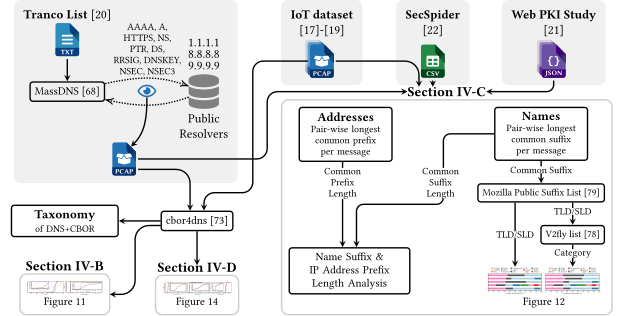

In [3]:
%%tikz -p "$preamble" -S 04_cbor4dns_eval/figs/dns-collect
\adjustbox{scale=1.4}{\input{04_cbor4dns_eval/figs/dns-collect.tex}}

## Dataset Collection

TBD remove this sentence: We provided the PCAP generated from the Tranco list, the SecSpider CSV and the Web PKI Study data [here][TBD].
For instructions how to collect your own Tranco list and how to get the IoT datasets, please have a look at [this notebook](./04_cbor4dns_eval/01_dataset_collection.ipynb).
Due to the size restrictions on Zenodo and for anonomyzation purposes, we only uploaded the calculated metrics as well as the histogram data generated from them there.
For their generation from the datasets, including intermediates, please have a look at
- [this notebook for `application/dns+cbor` encoding (including name compression)](./04_cbor4dns_eval/02_encoding.ipynb) and
- [this notebook to prepare the common IP prefixes and name suffixes analysis](./04_cbor4dns_eval/03_comp_pot_prep.ipynb).

If you only cloned the Git repository, you will only have the bare minimum files to generate the plots. You can find all other files in `04_cbor4dns_eval.tar.xz` on [Zenodo](https://tbd) and unpack them with the following command:

In [4]:
%%bash
wget -O 04_cbor4dns_eval.tar.xz https://tbd
md5sum --status -c "${DNSCBOR_EVAL_DIR}"/04_cbor4dns_eval.tar.xz.md5sum && \
    XZ_OPT=-T0 tar -C "${DNSCBOR_EVAL_DIR}/.." -xJf 04_cbor4dns_eval.tar.xz

Additonal `xx_*.ipynb` notebooks in the `04_cbor4dns_eval/` directory provide context for certain `application/dns+cbor` and Packed CBOR design decisions.

## CDF Plotting Definition

In [5]:
LABELS = {
    "Queries application/dns-message vs application/cbor+dns gain": "Queries (unpacked)",
    "Responses (w/o question) application/dns-message vs application/cbor+dns gain": "Responses (w/o question, unpacked)",
    "Responses (w/o question) application/dns-message vs application/cbor+dns;packed=1 gain": "Responses (w/o question, packed)",
    "Responses (w/ question) application/dns-message vs application/cbor+dns gain": "Responses (w/ question, unpacked)",
    "Responses (w/ question) application/dns-message vs application/cbor+dns;packed=1 gain": "Responses (w/ question, packed)",
    "Queries application/dns-message vs application/cbor+dns byte savings": "Queries (unpacked)",
    "Responses (w/o question) application/dns-message vs application/cbor+dns byte savings": "Responses (w/o question, unpacked)",
    "Responses (w/o question) application/dns-message vs application/cbor+dns;packed=1 byte savings": "Responses (w/o question, packed)",
    "Responses (w/ question) application/dns-message vs application/cbor+dns byte savings": "Responses (w/ question, unpacked)",
    "Responses (w/ question) application/dns-message vs application/cbor+dns;packed=1 byte savings": "Responses (w/ question, packed)",
}
STYLES = {
    "Queries (unpacked)": "C0--",
    "Responses (w/o question, unpacked)": "C2:",
    "Responses (w/o question, packed)": "C2",
    "Responses (w/ question, unpacked)": "C1:",
    "Responses (w/ question, packed)": "C1",
}


def construct_df(files, ignore_cols_with=None, **filter_params):
    def col_ignored(col):
        return not any(
            icol in col
            for icol in ignore_cols_with
        )
        
    read_params = {}
    if ignore_cols_with:
        read_params["usecols"] = col_ignored
    df = pandas.concat(
        pandas.read_csv(file, dtype={"w_query": bool}, **read_params) for file in files
    )

    columns = {}
    for col in df.columns:
        match = re.search(r"(.*) hist \[bin_size = [0-9.]+\]", col)
        if match:
            columns[col] = match[1]
    df = df.rename(columns=columns)
    
    filter = True
    if filter_params.get("datasets"):
        filter &= df["dataset"].isin(filter_params["datasets"])
    if filter_params.get("msgs"):
        filter &= df["msg"].isin(filter_params["msgs"])
    if filter_params.get("prots"):
        filter &= df["protocol"].isin(filter_params["prots"])
    if filter_params.get("qtypes"):
        filter &= df["qtype"].isin(filter_params["qtypes"])
    if filter_params.get("with_question"):
        filter &= df["w_query"].isin([not b for b in filter_params["with_question"]])
    try:
        res = (
            df[filter & (df["msg"] == "q")][
                ["x"] + list(columns.values())
            ].dropna(axis=1, how="all").groupby("x").sum(min_count=1).sort_index().add_prefix("Queries ")
        )
    except KeyError:
        res = pandas.DataFrame()
    try:
        res = res.join(
            df[filter & (df["msg"] == "r") & df["w_query"]][
                ["x"] + list(columns.values())
            ].dropna(axis=1, how="all").groupby("x").sum(min_count=1).sort_index().add_prefix("Responses (w/o question) "),
            how="outer",
        )
    except KeyError:
        pass
    try:
        res = res.join(
            df[filter & (df["msg"] == "r") & ~df["w_query"]][
                ["x"] + list(columns.values())
            ].dropna(axis=1, how="all").groupby("x").sum(min_count=1).sort_index().add_prefix("Responses (w/ question) "),
            how="outer",
        )
    except KeyError:
        pass
    return res


def mean_bin(df, column):
    # https://stackoverflow.com/a/37265494
    sdf = df.reset_index(drop=False, names=["bin"]).sort_values(column).reset_index(drop=True)
    mean_idx = sdf[column].searchsorted(sdf[column].mean())
    if mean_idx > 0:
        res = sdf.loc[mean_idx - 1]
        return res["bin"]
    return numpy.nan


def std_bin(df, column):
    sdf = df.reset_index(drop=False, names=["bin"]).sort_values(column).reset_index(drop=True)
    std_idx = sdf[column].searchsorted(sdf[column].std())
    if std_idx > 0:
        res = sdf.loc[std_idx - 1]
        return res["bin"]
    return numpy.nan


def median_bin(df, column):
    # https://math.stackexchange.com/a/2591986
    total = 0
    median_index = (df[column].sum() + 1) / 2
    for value in df.index.sort_values():
        total += df.loc[value].fillna(0)[column]
        if total > median_index:
            return value
    return numpy.nan


def plot_cdf(
    files,
    output_name,
    xlabel,
    stats_unit,
    stats_func=lambda x: x,
    zero_line=0,
    datasets=None,
    prots=None,
    msgs=None,
    qtypes=None,
    with_question=None,
    ignore_cols_with=None,
    xlim=None,
    xticks=None,
    yticks_show=True,
    xaxis_formatter=None,
    xaxis_minor_locator=None,
    inset_axes_params=None,
    indicate_inset_zoom_params={
        "edgecolor": "black",
        "linewidth": 0.5,
    },
    styles=STYLES,
    labels=LABELS,
    legend_loc=None,
    legend_ncol=5,
    legend_offset=.5,
    legend_order=None,
    legend_fontsize="xx-small",
    color_cycler=None,
    stylesheet="column",
    figsize_factor=(1.16, 0.5),
    plot_label=None,
):
    df = construct_df(
        files,
        ignore_cols_with=ignore_cols_with,
        datasets=datasets,
        prots=prots,
        msgs=msgs,
        qtypes=qtypes,
        with_question=with_question,
    )
    if df.empty:
        return df
    matplotlib.pyplot.clf()
    matplotlib.style.use(pathlib.Path.cwd() / f"mlenders_{stylesheet}.mplstyle")
    matplotlib.rcParams["figure.figsize"] = (
        matplotlib.rcParams["figure.figsize"][0] * figsize_factor[0],
        matplotlib.rcParams["figure.figsize"][1] * figsize_factor[1],
    )
    matplotlib.rcParams["legend.fontsize"] = legend_fontsize
    matplotlib.rcParams["legend.handlelength"] = 1.5
    if stylesheet == "fullslide":
        matplotlib.pyplot.gcf()
        matplotlib.pyplot.close("all")
        matplotlib.use("pgf")
    else:
        matplotlib.pyplot.gcf()
        matplotlib.pyplot.close("all")
        matplotlib.use("inline")
    if not color_cycler:
        color_cycler = ["#030303", "#5e3c99", "#f1a340"]
    matplotlib.pyplot.rc("axes", prop_cycle=cycler.cycler(color=color_cycler))
    
    fig = matplotlib.pyplot.figure(
        figsize=matplotlib.rcParams["figure.figsize"],
        dpi=150,
    )
    ax = matplotlib.pyplot.gca()
    
    if inset_axes_params:
        inset_axis_xformatter = inset_axes_params.pop("xaxis_formatter", None)
        inset_axis_xminor_locator = inset_axes_params.pop("xminor_locator", None)
        inset_axis_yminor_locator = inset_axes_params.pop("yminor_locator", None)
        axins = ax.inset_axes(**inset_axes_params)
    else:
        inset_axis_xformatter = None
        inset_axis_xminor_locator = None
        inset_axis_yminor_locator = None
        axins = None
    if xlim is None:
        if xticks is not None:
            ax.set_xlim((list(xticks)[0] - 0.01, list(xticks)[-1] + 0.01))
    else:
        ax.set_xlim(xlim)
    if xticks is not None:
        ax.set_xticks(xticks)
    if xaxis_formatter:
        ax.xaxis.set_major_formatter(xaxis_formatter)
    if xaxis_minor_locator:
        ax.xaxis.set_minor_locator(xaxis_minor_locator)

    if yticks_show:
        ax.set_ylabel("CDF")
    else:
        ax.set_yticklabels([])
    ax.set_ylim((-0.02, 1.02))
    ax.set_yticks(numpy.arange(0, 1.05, 0.2 if figsize_factor[1] < 0.5 else 0.1))
    ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.1 if figsize_factor[1] < 0.5 else 0.05))
    
    df.index = df.index.rename("")
    stats = pandas.DataFrame(
        {
            "size [#]": {
                c: int(df[c].sum()) for c in df.columns
            },
            f"mean [{stats_unit}]": {
                c: stats_func(mean_bin(df, c)) for c in df.columns
            },
            f"std [{stats_unit}]": {
                c: stats_func(std_bin(df, c)) for c in df.columns
            },
            f"min [{stats_unit}]": {
                c: stats_func(df[c].dropna().index.min()) for c in df.columns
            },
            f"median [{stats_unit}]": {
                c: stats_func(median_bin(df, c)) for c in df.columns
            },
            f"max [{stats_unit}]": {
                c: stats_func(df[c].dropna().index.max()) for c in df.columns
            },
        }
    ).rename(index=labels)
    IPython.display.display(stats)
    if prots is None and datasets is None and qtypes is None:
        print(stats.to_latex(float_format=lambda x: f"{x:0.1f}", escape=True))
    cdf = (df.cumsum() / df.sum()).interpolate(limit_area="inside").rename(columns=labels)
    cdf.plot(ax=ax, style=styles, legend=None, xlabel=xlabel)

    if axins:
        cdf.plot(ax=axins, style=styles, legend=None, xlabel="")
        if indicate_inset_zoom_params:
            connector_line_visibility = indicate_inset_zoom_params.pop("connector_line_visibility", [])
            _, connector_lines = ax.indicate_inset_zoom(axins, **indicate_inset_zoom_params)
            if connector_line_visibility:
                for i, visible in enumerate(connector_line_visibility):
                    if i >= len(connector_lines):
                        break
                    connector_lines[i].set(visible=visible)
                for i in range(len(connector_line_visibility), len(connector_lines)):
                    connector_lines[i].set(visible=False)
        if inset_axis_xformatter is not None:
            axins.xaxis.set_major_formatter(inset_axis_xformatter)
        if inset_axis_xminor_locator is not None:
            axins.xaxis.set_minor_locator(inset_axis_xminor_locator)
        if inset_axis_yminor_locator is not None:
            axins.yaxis.set_minor_locator(inset_axis_yminor_locator)
        if "xlabel" in inset_axes_params:
            axins.set_xlabel(inset_axes_params["xlabel"])
    
    if plot_label:
        ax.text(xlim[1] - ((xlim[1] - xlim[0]) * 0.005), 0, plot_label, fontsize=matplotlib.rcParams["legend.title_fontsize"], ha="right")
    matplotlib.pyplot.savefig(
        output_name,
        bbox_inches="tight",
        pad_inches=0.01,
    )
    if legend_loc:
        handles, labels = ax.get_legend_handles_labels()
        if legend_order:
            assert set(legend_order) == set(labels), (
                f"legend_order {legend_order} does not fit actual labels {labels}"
            )
            orig_handles = handles
            orig_labels = labels
            handles = []
            labels = []
            for label in legend_order:
                labels.append(label)
                handles.append(orig_handles[orig_labels.index(label)])
        ax.legend(
            handles=handles,
            labels=labels,
            loc=legend_loc,
            bbox_to_anchor=(0.5, 1.0 + legend_offset) if legend_offset is not None else None,
            ncol=legend_ncol
        )
        matplotlib.pyplot.savefig(
            str(output_name).replace(".pdf", "_legend.pdf"),
            bbox_inches="tight",
            pad_inches=0.01,
        )
    matplotlib.pyplot.show()
    matplotlib.pyplot.close()
    return df

## The application/dns+cbor DNS Message Format

Here, we generate the plots and data presented in Section IV.B, “The application/dns+cbor DNS Message Format”, of our paper.

### Taxonomy

##### Unpacked/Packed

###### Tier

,Tier 1,Tier 2,Tier 3
All,0.985417,0.014362,0.000221
Unpacked,0.991313,0.008561,0.000126
Packed,0.940038,0.059008,0.000954


[`dns_cbor_classic_taxonomy_tier.pdf`](04_cbor4dns_eval/plots/dns_cbor_classic_taxonomy_tier.pdf)

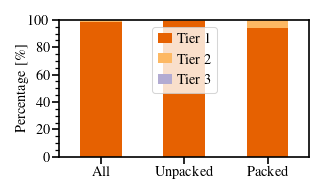

###### Content Type

,Binary,Numeric,Textual,Taggy
All,0.106745,0.113607,0.767852,0.011795
Unpacked,0.061170,0.075443,0.863236,0.000151
Packed,0.457487,0.407323,0.033778,0.101412


[`dns_cbor_classic_taxonomy_content_type.pdf`](04_cbor4dns_eval/plots/dns_cbor_classic_taxonomy_content_type.pdf)

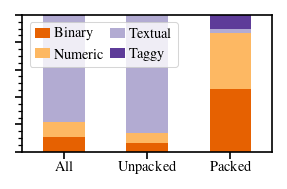

###### Redundancy

,Non-redundant,Redundant
All,0.991015,0.008985
Unpacked,0.994026,0.005974
Packed,0.967842,0.032158


[`dns_cbor_classic_taxonomy_redundancy.pdf`](04_cbor4dns_eval/plots/dns_cbor_classic_taxonomy_redundancy.pdf)

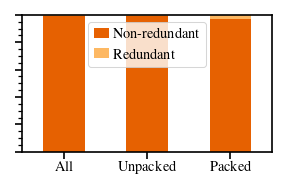

###### Structure

,Flat,Nested
All,0.934400,0.065600
Unpacked,1.000000,NaN
Packed,0.429536,0.570464


[`dns_cbor_classic_taxonomy_structure.pdf`](04_cbor4dns_eval/plots/dns_cbor_classic_taxonomy_structure.pdf)

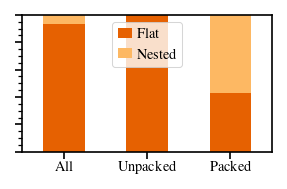

In [6]:
ONLY_PAPER = True      # set to False to plot with filters based on taxonomy
# LABEL_YTICKS = True    # set to False if you want to omit the labels of the y-axis (like in the paper)
LABEL_YTICKS = False

matplotlib.style.use(pathlib.Path.cwd() / "mlenders_halfcolumn_ieeetran.mplstyle")
matplotlib.rcParams["figure.figsize"] = (
    matplotlib.rcParams["figure.figsize"][0] * 1.12,
    # matplotlib.rcParams["figure.figsize"][1] * 0.75,
    matplotlib.rcParams["figure.figsize"][1] * 1.0,
)
# matplotlib.rcParams["legend.fontsize"] = 4
matplotlib.rcParams["legend.columnspacing"] = 0.4
matplotlib.rcParams["legend.handletextpad"] = 0.3
matplotlib.rcParams["axes.prop_cycle"] = matplotlib.pyplot.cycler(
    "color",
    ["#e66101", "#fdb863", "#b2abd2", "#5e3c99"]
)


def qtype_filter(df, qtype):
    return ~df["packed"] & (df["qtype"] == qtype)


QTYPES = [
    "A", "NS", "SOA", "PTR", "HINFO", "TXT", "AAAA", "SRV", "DS", "RRSIG", "NSEC", "DNSKEY", "NSEC3", "HTTPS", "ANY"
]
FILTERS = {
    "packed": [lambda df: ~df["packed"], lambda df: df["packed"]],
    "protocol": [
        lambda df: ~df["packed"] & (df["protocol"] == "dns"),
        lambda df: ~df["packed"] & (df["protocol"] == "mdns"),
        lambda df: ~df["packed"] & (df["protocol"] == "llmnr"),
    ],
    "msg": [lambda df: df["msg"] == "q", lambda df: ~df["packed"] & (df["msg"] == "r")],
    "qtype": [functools.partial(qtype_filter, qtype=qtype) for qtype in QTYPES],
    "w_query": [lambda df: ~df["packed"] & ~df["w_query"], lambda df: ~df["packed"] & df["w_query"]],
    "dataset": [
        lambda df: ~df["packed"] & df["dataset"].isin(["yourthings", "moniotr", "iotfinder"]),
        lambda df: ~df["packed"] & (df["dataset"] == "tranco"),
    ],
}
INDEX = {
    "packed": {0: "All", 1: "Unpacked", 2: "Packed"},
    "protocol": {0: "All", 1: "DNS", 2: "mDNS", 3: "LLMNR"},
    "msg": {0: "All", 1: "Queries", 2: "Responses"},
    "qtype": {i: qtype for i, qtype in [(0, "All")] + list(enumerate(QTYPES, start=1))},
    "w_query": {0: "All", 1: "w/o query", 2: "w/ query"},
    "dataset": {0: "All", 1: "IoT", 2: "Tranco"},
}
TITLE = {
    "packed": "Unpacked/Packed",
    "protocol": "Protocol",
    "msg": "Message Type",
    "qtype": "Query Type",
    "w_query": "With or Without Query",
    "dataset": "Dataset",
}
CATEGORIES = ["tier", "content type", "redundancy", "structure"]

for filt in ["packed", "protocol", "msg", "qtype", "w_query", "dataset"]:
    IPython.display.display(IPython.display.Markdown(f"##### {TITLE[filt]}"))
    for category in CATEGORIES:
        IPython.display.display(IPython.display.Markdown(f"###### {category.title()}"))
        df = pandas.read_csv(
            DNSCBOR_EVAL_DIR / "output_datasets" / f"dns_cbor_classic_taxonomy_{category.replace(" ", "_")}.csv",
        )
        df = pandas.concat(
            [
                (df.groupby([category])["size"].sum().to_frame() / df["size"].sum()).T
                if filt == "packed"
                else (df[~df["packed"]].groupby([category])["size"].sum().to_frame() / df[~df["packed"]]["size"].sum()).T,
            ] + [
                (df[f(df)].groupby([category])["size"].sum().to_frame() / df[f(df)]["size"].sum()).T
                for f in FILTERS[filt]
            ],
            ignore_index=True
        )
        if category == "tier":
            df.columns = [f"Tier {c}" for c in df.columns]
        elif category == "content type":
            df = df.reindex(["structural", "boolean", "binary", "numeric", "textual", "taggy"], axis=1)
            df.columns = [c.title() for c in df.columns]
        elif category == "redundancy":
            df.columns = [c.title() if c == "redundant" else "Non-redundant" for c in df.columns]
        else:
            df.columns = [c.title() for c in df.columns]
        df = df.loc[:, df[df != 0].any(axis=0)].rename(index=INDEX[filt]) # .dropna(how="all")
        IPython.display.display(IPython.display.HTML(df.to_html()))
        
        fig = matplotlib.pyplot.figure(
            figsize=matplotlib.rcParams["figure.figsize"],
            dpi=150,
        )
        ax = matplotlib.pyplot.gca()
        ax = df.plot.bar(ax=ax, stacked=True, legend=False, rot=0)
        
        ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1, symbol=""))
        ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.05))
        ax.set_ylim((0, 1))
        ax.set_yticks(numpy.arange(0, 1.1, 0.2))
        if category == "tier" or LABEL_YTICKS:
            ax.set_ylabel(r"Percentage [\%]")
        else:
            ax.set_yticklabels([])
        if filt == "qtype":
            matplotlib.pyplot.xticks(rotation=90, ha="center")
        ax.legend(loc="upper center" if category != "content type" else "upper left", ncol=1 if category != "content type" else 2)
        filename = f"dns_cbor_classic_taxonomy_{category.replace(" ", "_")}{"" if filt == "packed" else f"_{filt}_unpacked"}.pdf"
        matplotlib.pyplot.savefig(
            DNSCBOR_EVAL_DIR / "plots" / filename,
            bbox_inches="tight",
            pad_inches=0.01
        )
        IPython.display.display(
            IPython.display.Markdown(
                f"[`{filename}`]"
                f"({DNSCBOR_EVAL_DIR.relative_to(pathlib.Path.cwd()) / 'plots' / filename})"
            )
        )
        matplotlib.pyplot.show()
        matplotlib.pyplot.close("all")
    if ONLY_PAPER:
        break

### Plot Gain & Byte Savings for `draft-lendes-dns-cbor-06`

This section requires the cell under [CDF Plotting Definition](#CDF-Plotting-Definition) to be run.


#### Gain [`cbor+dns-gain-all.pdf`](04_cbor4dns_eval/plots/cbor+dns-gain-all.pdf)

,size [#],mean [%],std [%],min [%],median [%],max [%]
Queries (unpacked),454499666,46.1,24.3,-6.3,32.3,88.5
"Responses (w/o question, unpacked)",65787247,14.0,24.3,-223.9,30.8,95.5
"Responses (w/o question, packed)",65787247,7.5,23.5,-130.0,34.7,93.8
"Responses (w/ question, unpacked)",2088333,-32.8,45.3,-216.8,23.8,47.8
"Responses (w/ question, packed)",2088333,34.3,24.1,-47.2,23.7,52.4


\begin{tabular}{lrrrrrr}
\toprule
 & size [\#] & mean [\%] & std [\%] & min [\%] & median [\%] & max [\%] \\
\midrule
Queries (unpacked) & 454499666 & 46.1 & 24.3 & -6.3 & 32.3 & 88.5 \\
Responses (w/o question, unpacked) & 65787247 & 14.0 & 24.3 & -223.9 & 30.8 & 95.5 \\
Responses (w/o question, packed) & 65787247 & 7.5 & 23.5 & -130.0 & 34.7 & 93.8 \\
Responses (w/ question, unpacked) & 2088333 & -32.8 & 45.3 & -216.8 & 23.8 & 47.8 \\
Responses (w/ question, packed) & 2088333 & 34.3 & 24.1 & -47.2 & 23.7 & 52.4 \\
\bottomrule
\end{tabular}



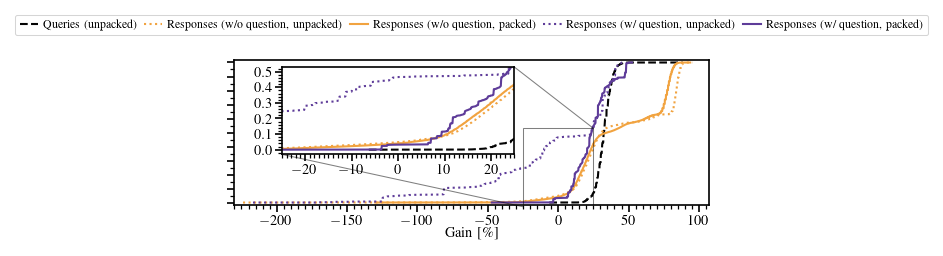

In [7]:
SLIDE_VERSION = False  # set to true for styling for slide set
ONLY_PAPER = True      # set to False to plot with filters based message types and datasets
# LABEL_YTICKS = True    # set to False if you want to omit the labels of the y-axis (like in the paper)
LABEL_YTICKS = False


for datasets_name, datasets in [("all", None), ("iot", ["yourthings", "iotfinder", "moniotr"]), ("tranco", ["tranco"]), ("oarc-ditl", ["DITL-20240409"])]:
    for prots_name, prots in [("", None), ("-wo_mdns", ["dns"])]:
        for qtype in [None, "A", "AAAA"]:
            if qtype is None:
                qtypes = None
                qtypes_name = ""
            else:
                qtypes = [qtype]
                qtypes_name = f"-{qtype}"

            filename = f"cbor+dns-gain-{datasets_name}{prots_name}{qtypes_name}.pdf"
            IPython.display.display(
                IPython.display.Markdown(
                    f"#### Gain [`{filename}`]"
                    f"({DNSCBOR_EVAL_DIR.relative_to(pathlib.Path.cwd()) / 'plots' / filename})"
                )
            )
            plot_cdf(
                [
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_classic_hist_gain_iot.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_classic_hist_gain_tranco.csv",
                    # DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_classic_hist_gain_ditl_a-root_sfo8-a.csv",
                ],
                DNSCBOR_EVAL_DIR / "plots" / filename,
                r"Gain [\%]",
                "%",
                stats_func=lambda x: 100 * x,
                datasets=datasets,
                prots=prots,
                qtypes=qtypes,
                xlim=(-2.3, 1.07),
                xticks=numpy.arange(-2.00, 1.25, 0.5),
                xaxis_formatter=matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x * 100:0.0f}$"),
                xaxis_minor_locator=matplotlib.ticker.MultipleLocator(0.05),
                yticks_show=LABEL_YTICKS,
                inset_axes_params={
                    "bounds": [0.10, 0.35, 0.49, 0.6],
                    "xlim": (-0.25, 0.25),
                    "xticks": numpy.arange(-0.20, 0.25, 0.10),
                    "ylim": (-0.03, 0.53),
                    "yticks": numpy.arange(0.0, 0.6, 0.1),
                    "xaxis_formatter": matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x * 100:0.0f}$"),
                    "xminor_locator": matplotlib.ticker.MultipleLocator(0.01),
                    "yminor_locator": matplotlib.ticker.MultipleLocator(0.02),
                },
                stylesheet="column_ieeetran" if not SLIDE_VERSION else "fullslide",
                figsize_factor=(1, 4 / 8),
                legend_loc="upper center",
                legend_ncol=5,
                legend_offset=.35,
            )
            if ONLY_PAPER:
                break
        if ONLY_PAPER:
            break
    if ONLY_PAPER:
        break

#### Byte Savings [`cbor+dns-savings-all.pdf`](04_cbor4dns_eval/plots/cbor+dns-savings-all.pdf)

,size [#],mean [bytes],std [bytes],min [bytes],median [bytes],max [bytes]
Queries (unpacked),454499666,14.0,9.0,-7,10,202
"Responses (w/o question, unpacked)",65787247,-21.0,41.0,-1181,25,8751
"Responses (w/o question, packed)",65787247,49.0,40.0,-165,23,13084
"Responses (w/ question, unpacked)",2088333,-392.0,38.0,-760,15,110
"Responses (w/ question, packed)",2088333,64.0,50.0,-41,17,260


\begin{tabular}{lrrrrrr}
\toprule
 & size [\#] & mean [bytes] & std [bytes] & min [bytes] & median [bytes] & max [bytes] \\
\midrule
Queries (unpacked) & 454499666 & 14.0 & 9.0 & -7 & 10 & 202 \\
Responses (w/o question, unpacked) & 65787247 & -21.0 & 41.0 & -1181 & 25 & 8751 \\
Responses (w/o question, packed) & 65787247 & 49.0 & 40.0 & -165 & 23 & 13084 \\
Responses (w/ question, unpacked) & 2088333 & -392.0 & 38.0 & -760 & 15 & 110 \\
Responses (w/ question, packed) & 2088333 & 64.0 & 50.0 & -41 & 17 & 260 \\
\bottomrule
\end{tabular}



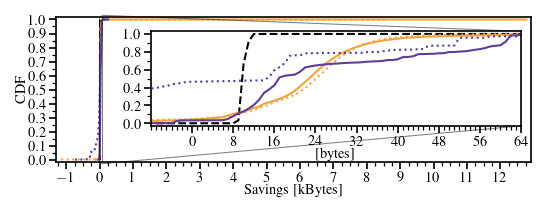

In [8]:
SLIDE_VERSION = False  # set to true for styling for slide set
ONLY_PAPER = True      # set to False to plot with filters based message types and datasets
LABEL_YTICKS = True    # set to False if you want to omit the labels of the y-axis (like in the paper)


for datasets_name, datasets in [("all", None), ("iot", ["yourthings", "iotfinder", "moniotr"]), ("tranco", ["tranco"]), ("oarc-ditl", ["DITL-20240409"])]:
    for prots_name, prots in [("", None), ("-wo_mdns", ["dns"])]:
        for qtype in [None, "A", "AAAA"]:
            if qtype is None:
                qtypes = None
                qtypes_name = ""
            else:
                qtypes = [qtype]
                qtypes_name = f"-{qtype}"

            filename = f"cbor+dns-savings-{datasets_name}{prots_name}{qtypes_name}.pdf"
            IPython.display.display(
                IPython.display.Markdown(
                    f"#### Byte Savings [`{filename}`]"
                    f"({DNSCBOR_EVAL_DIR.relative_to(pathlib.Path.cwd()) / 'plots' / filename})"
                )
            )
            plot_cdf(
                [
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_classic_hist_savings_iot.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_classic_hist_savings_tranco.csv",
                    # DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_classic_hist_savings_ditl_a-root_sfo8-a.csv",
                ],
                DNSCBOR_EVAL_DIR / "plots" / filename,
                "Savings [kBytes]",
                "bytes",
                datasets=datasets,
                prots=prots,
                qtypes=qtypes,
                xlim=(-1.3 * 1024, 12.9 * 1024),
                xticks=numpy.arange(-1024, 13 * 1024, 1024),
                xaxis_formatter=matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x // 1024}$"),
                xaxis_minor_locator=matplotlib.ticker.MultipleLocator(0.25 * 1024),
                yticks_show=LABEL_YTICKS,
                inset_axes_params={
                    "bounds": [0.2, 0.25, 0.78, 0.65],
                    "xlim": (-8, 64),
                    "xticks": numpy.arange(0, 65, 8),
                    "xlabel": "[bytes]",
                    "ylim": (-0.03, 1.03),
                    "yticks": numpy.arange(0, 1.1, 0.2),
                    "xaxis_formatter": matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x:0.0f}$"),
                    "xminor_locator": matplotlib.ticker.MultipleLocator(1),
                    "yminor_locator": matplotlib.ticker.MultipleLocator(0.1),
                },
                stylesheet="column_ieeetran" if not SLIDE_VERSION else "fullslide",
                figsize_factor=(1.0, 4 / 8),
            )
            if ONLY_PAPER:
                break
        if ONLY_PAPER:
            break
    if ONLY_PAPER:
        break

## Name Compression in Unpacked `application/dns+cbor`

Here, we generate the plots and data presented in Section IV.D, “Name Compression in Unpacked application/dns+cbor”, of our paper.

This section requires the cell under [CDF Plotting Definition](#CDF-Plotting-Definition) to be run.

### Queries

#### Gain [`cbor+dns-name-comp-queries-gain-all.pdf`](04_cbor4dns_eval/plots/cbor+dns-name-comp-queries-gain-all.pdf)

,size [#],mean [%],std [%],min [%],median [%],max [%]
Draft-06 (unpacked),454499666,46.1,24.3,-6.3,32.3,88.5
Component Referencing (1+0 tag),454499666,46.1,24.3,-6.3,32.3,88.5
Component Referencing (1+1 tag),454499666,46.1,24.3,-6.3,32.3,88.5


\begin{tabular}{lrrrrrr}
\toprule
 & size [\#] & mean [\%] & std [\%] & min [\%] & median [\%] & max [\%] \\
\midrule
Draft-06 (unpacked) & 454499666 & 46.1 & 24.3 & -6.3 & 32.3 & 88.5 \\
Component Referencing (1+0 tag) & 454499666 & 46.1 & 24.3 & -6.3 & 32.3 & 88.5 \\
Component Referencing (1+1 tag) & 454499666 & 46.1 & 24.3 & -6.3 & 32.3 & 88.5 \\
\bottomrule
\end{tabular}



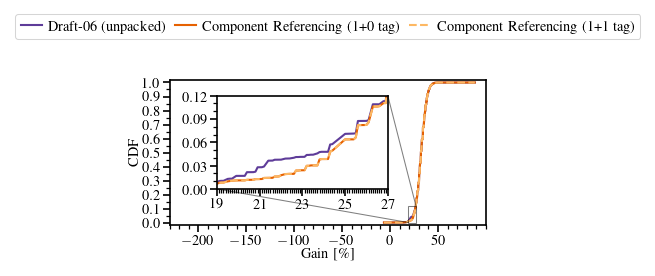

In [9]:
SLIDE_VERSION = False  # set to true for styling for slide set
ONLY_PAPER = True      # set to False to plot with filters based message types and datasets

for datasets_name, datasets in [("all", None), ("iot", ["yourthings", "iotfinder", "moniotr"]), ("tranco", ["tranco"]), ("oarc-ditl", ["DITL-20240409"])]:
    for prots_name, prots in [("", None), ("-wo_mdns", ["dns"])]:
        for qtype in [None, "A", "AAAA"]:
            if qtype is None:
                qtypes = None
                qtypes_name = ""
            else:
                qtypes = [qtype]
                qtypes_name = f"-{qtype}"

            filename = f"cbor+dns-name-comp-queries-gain-{datasets_name}{prots_name}{qtypes_name}.pdf"
            IPython.display.display(
                IPython.display.Markdown(
                    f"#### Gain [`{filename}`]"
                    f"({DNSCBOR_EVAL_DIR.relative_to(pathlib.Path.cwd()) / 'plots' / filename})"
                )
            )
            plot_cdf(
                [
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_classic_hist_gain_iot.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp7_hist_gain_iot.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp48_hist_gain_iot.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_classic_hist_gain_tranco.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp7_hist_gain_tranco.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp48_hist_gain_tranco.csv",
                    # DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_classic_hist_gain_ditl_a-root_sfo8-a.csv",
                    # DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp7_hist_gain_ditl_a-root_sfo8-a.csv",
                    # DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp48_hist_gain_ditl_a-root_sfo8-a.csv",
                ],
                DNSCBOR_EVAL_DIR / "plots" / filename,
                r"Gain [\%]",
                "%",
                stats_func=lambda x: 100 * x,
                datasets=datasets,
                prots=prots,
                msgs=["q"],
                qtypes=qtypes,
                with_question=[True],
                #xlim=(-0.1, 0.90),
                #xticks=numpy.arange(-0.1, 0.9, 0.1),
                #xaxis_formatter=matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x * 100:0.0f}$"),
                #xaxis_minor_locator=matplotlib.ticker.MultipleLocator(0.02),
                xlim=(-2.3, 1.0),
                xticks=numpy.arange(-2.0, 1.0, 0.5),
                xaxis_formatter=matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x * 100:0.0f}$"),
                xaxis_minor_locator=matplotlib.ticker.MultipleLocator(0.1),
                labels={
                    "Queries application/dns-message vs application/cbor+dns gain": "Draft-06 (unpacked)",
                    "Queries application/dns-message vs application/cbor+dns t7 gain": "Component Referencing (1+0 tag)",
                    "Queries application/dns-message vs application/cbor+dns t48 gain": "Component Referencing (1+1 tag)",
                },
                styles={
                    "Draft-06 (unpacked)": "C0",
                    "Component Referencing (1+0 tag)": "C1",
                    "Component Referencing (1+1 tag)": "C2--",
                    "Packed Lite": "C3",
                },
                legend_loc="upper center",
                legend_fontsize="x-small",
                color_cycler=["#5e3c99", "#e66101", "#fdb863", "#b2abd2"],
                inset_axes_params={
                    "bounds": [0.15, 0.25, 0.54, 0.64],
                    "xlim": (0.19, 0.27),
                    "xticks": numpy.arange(.19, 0.27, 0.01) if SLIDE_VERSION else numpy.arange(.19, 0.27, 0.02),
                    "ylim": (-0.00, 0.12),
                    "yticks": numpy.arange(0.0, 0.13, 0.03),
                    "xaxis_formatter": matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x * 100:0.0f}$"),
                    "xminor_locator": matplotlib.ticker.MultipleLocator(0.001),
                    "yminor_locator": matplotlib.ticker.MultipleLocator(0.01),
                },
                stylesheet="column_ieeetran" if not SLIDE_VERSION else "fullslide",
                figsize_factor=(2 / 3, 4 / 8),
                plot_label="Queries" if SLIDE_VERSION else None,
            )
            if ONLY_PAPER:
                break
        if ONLY_PAPER:
            break
    if ONLY_PAPER:
        break

#### Byte Savings [`cbor+dns-name-comp-queries-savings-all.pdf`](04_cbor4dns_eval/plots/cbor+dns-name-comp-queries-savings-all.pdf)

,size [#],mean [bytes],std [bytes],min [bytes],median [bytes],max [bytes]
Draft-06 (unpacked),454499666,14.0,9.0,-7,10,202
Component Referencing (1+0 tag),454499666,9.0,9.0,-7,10,202
Component Referencing (1+1 tag),454499666,9.0,9.0,-7,10,202


\begin{tabular}{lrrrrrr}
\toprule
 & size [\#] & mean [bytes] & std [bytes] & min [bytes] & median [bytes] & max [bytes] \\
\midrule
Draft-06 (unpacked) & 454499666 & 14.0 & 9.0 & -7 & 10 & 202 \\
Component Referencing (1+0 tag) & 454499666 & 9.0 & 9.0 & -7 & 10 & 202 \\
Component Referencing (1+1 tag) & 454499666 & 9.0 & 9.0 & -7 & 10 & 202 \\
\bottomrule
\end{tabular}



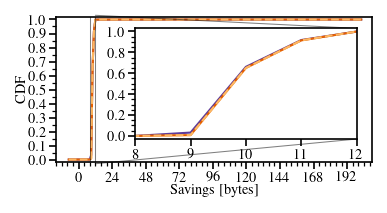

In [10]:
SLIDE_VERSION = False  # set to true for styling for slide set
ONLY_PAPER = True      # set to False to plot with filters based message types and datasets

for datasets_name, datasets in [("all", None), ("iot", ["yourthings", "iotfinder", "moniotr"]), ("tranco", ["tranco"]), ("oarc-ditl", ["DITL-20240409"])]:
    for prots_name, prots in [("", None), ("-wo_mdns", ["dns"])]:
        for qtype in [None, "A", "AAAA"]:
            if qtype is None:
                qtypes = None
                qtypes_name = ""
            else:
                qtypes = [qtype]
                qtypes_name = f"-{qtype}"

            filename = f"cbor+dns-name-comp-queries-savings-{datasets_name}{prots_name}{qtypes_name}.pdf"
            IPython.display.display(
                IPython.display.Markdown(
                    f"#### Byte Savings [`{filename}`]"
                    f"({DNSCBOR_EVAL_DIR.relative_to(pathlib.Path.cwd()) / 'plots' / filename})"
                )
            )
            plot_cdf(
                [
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_classic_hist_savings_iot.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp7_hist_savings_iot.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp48_hist_savings_iot.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_classic_hist_savings_tranco.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp7_hist_savings_tranco.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp48_hist_savings_tranco.csv",
                    # DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_classic_hist_savings_ditl_a-root_sfo8-a.csv",
                    # DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp7_hist_savings_ditl_a-root_sfo8-a.csv",
                    # DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp48_hist_savings_ditl_a-root_sfo8-a.csv",
                ],
                DNSCBOR_EVAL_DIR / "plots" / filename,
                "Savings [bytes]",
                "bytes",
                datasets=datasets,
                prots=prots,
                msgs=["q"],
                qtypes=qtypes,
                with_question=[True],
                xlim=(-16, 210),
                xticks=numpy.arange(0, 211, 24),
                xaxis_minor_locator=matplotlib.ticker.MultipleLocator(4),
                labels={
                    "Queries application/dns-message vs application/cbor+dns byte savings": "Draft-06 (unpacked)",
                    "Queries application/dns-message vs application/cbor+dns t7 byte savings": "Component Referencing (1+0 tag)",
                    "Queries application/dns-message vs application/cbor+dns t48 byte savings": "Component Referencing (1+1 tag)",
                },
                styles={
                    "Draft-06 (unpacked)": "C0",
                    "Component Referencing (1+0 tag)": "C1",
                    "Component Referencing (1+1 tag)": "C2--",
                    "Packed Lite": "C3",
                },
                inset_axes_params={
                    "bounds": [0.25, 0.16, 0.70, 0.76],
                    "xlim": (8, 12),
                    "xticks": numpy.arange(8, 13, 1),
                    "ylim": (-0.03, 1.03),
                    "yticks": numpy.arange(0.0, 1.1, 0.2),
                    "xminor_locator": matplotlib.ticker.MultipleLocator(1),
                    "yminor_locator": matplotlib.ticker.MultipleLocator(0.05),
                },
                color_cycler=["#5e3c99", "#e66101", "#fdb863", "#b2abd2"],
                stylesheet="column_ieeetran" if not SLIDE_VERSION else "fullslide",
                figsize_factor=(2 / 3, 4 / 8),
                plot_label="Queries" if SLIDE_VERSION else None,
            )
            if ONLY_PAPER:
                break
        if ONLY_PAPER:
            break
    if ONLY_PAPER:
        break

### Responses (w/o question section)

#### Gain [`cbor+dns-name-comp-responses-woq-gain-all.pdf`](04_cbor4dns_eval/plots/cbor+dns-name-comp-responses-woq-gain-all.pdf)

,size [#],mean [%],std [%],min [%],median [%],max [%]
Packed Lite,65787247,40.7,20.9,-130.0,33.3,93.8
Draft-06 (unpacked),65787247,14.0,24.3,-223.9,30.8,95.5
Draft-06 (packed),65787247,7.5,23.5,-130.0,34.7,93.8
Component Referencing (1+0 tag),65787247,13.7,19.3,-82.7,36.0,95.5
Component Referencing (1+1 tag),65787247,-5.5,23.9,-83.5,35.5,95.5


\begin{tabular}{lrrrrrr}
\toprule
 & size [\#] & mean [\%] & std [\%] & min [\%] & median [\%] & max [\%] \\
\midrule
Packed Lite & 65787247 & 40.7 & 20.9 & -130.0 & 33.3 & 93.8 \\
Draft-06 (unpacked) & 65787247 & 14.0 & 24.3 & -223.9 & 30.8 & 95.5 \\
Draft-06 (packed) & 65787247 & 7.5 & 23.5 & -130.0 & 34.7 & 93.8 \\
Component Referencing (1+0 tag) & 65787247 & 13.7 & 19.3 & -82.7 & 36.0 & 95.5 \\
Component Referencing (1+1 tag) & 65787247 & -5.5 & 23.9 & -83.5 & 35.5 & 95.5 \\
\bottomrule
\end{tabular}



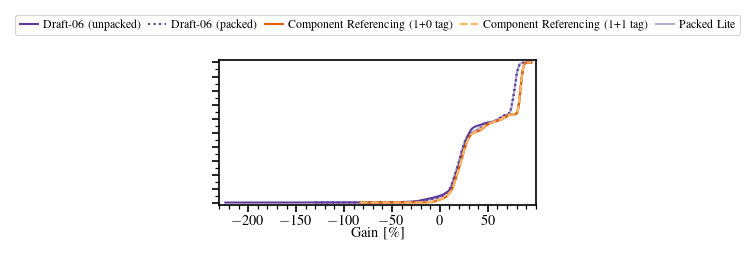

In [11]:
SLIDE_VERSION = False  # set to true for styling for slide set
ONLY_PAPER = True      # set to False to plot with filters based message types and datasets
# LABEL_YTICKS = True    # set to False if you want to omit the labels of the y-axis (like in the paper)
LABEL_YTICKS = False

for datasets_name, datasets in [("all", None), ("iot", ["yourthings", "iotfinder", "moniotr"]), ("tranco", ["tranco"]), ("oarc-ditl", ["DITL-20240409"])]:
    for prots_name, prots in [("", None), ("-wo_mdns", ["dns"])]:
        for qtype in [None, "A", "AAAA"]:
            if qtype is None:
                qtypes = None
                qtypes_name = ""
            else:
                qtypes = [qtype]
                qtypes_name = f"-{qtype}"

            filename = f"cbor+dns-name-comp-responses-woq-gain-{datasets_name}{prots_name}{qtypes_name}.pdf"
            IPython.display.display(
                IPython.display.Markdown(
                    f"#### Gain [`{filename}`]"
                    f"({DNSCBOR_EVAL_DIR.relative_to(pathlib.Path.cwd()) / 'plots' / filename})"
                )
            )
            plot_cdf(
                [
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_plite_hist_gain_iot.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_classic_hist_gain_iot.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp7_hist_gain_iot.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp48_hist_gain_iot.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_plite_hist_gain_tranco.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_classic_hist_gain_tranco.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp7_hist_gain_tranco.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp48_hist_gain_tranco.csv",
                    # DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_plite_hist_gain_ditl_a-root_sfo8-a.csv",
                    # DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_classic_hist_gain_ditl_a-root_sfo8-a.csv",
                    # DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp7_hist_gain_ditl_a-root_sfo8-a.csv",
                    # DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp48_hist_gain_ditl_a-root_sfo8-a.csv",
                ],
                DNSCBOR_EVAL_DIR / "plots" / filename,
                r"Gain [\%]",
                "%",
                lambda x: x * 100,
                datasets=datasets,
                prots=prots,
                msgs=["r"],
                qtypes=qtypes,
                with_question=[False],
                ignore_cols_with=[
                    "application/dns-message vs application/cbor+dns;packed=str-ref t7 gain",
                    "application/dns-message vs application/cbor+dns;packed=str-ref t48 gain",
                ],
                xlim=(-2.3, 1.0),
                xticks=numpy.arange(-2.0, 1.0, 0.5),
                xaxis_formatter=matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x * 100:0.0f}$"),
                xaxis_minor_locator=matplotlib.ticker.MultipleLocator(0.1),
                yticks_show=LABEL_YTICKS,
                labels={
                    "Responses (w/o question) application/dns-message vs application/cbor+dns gain": "Draft-06 (unpacked)",
                    "Responses (w/o question) application/dns-message vs application/cbor+dns;packed=1 gain": "Draft-06 (packed)",
                    "Responses (w/o question) application/dns-message vs application/cbor+dns;packed=lite gain": "Packed Lite",
                    "Responses (w/o question) application/dns-message vs application/cbor+dns t7 gain": "Component Referencing (1+0 tag)",
                    "Responses (w/o question) application/dns-message vs application/cbor+dns t48 gain": "Component Referencing (1+1 tag)",
                },
                styles={
                    "Draft-06 (unpacked)": "C0",
                    "Draft-06 (packed)": "C0:",
                    "Packed Lite": "C3",
                    "Component Referencing (1+0 tag)": "C1",
                    "Component Referencing (1+1 tag)": "C2--",
                },
                legend_loc="upper center",
                legend_offset=.35,
                legend_order=["Draft-06 (unpacked)", "Draft-06 (packed)", "Component Referencing (1+0 tag)", "Component Referencing (1+1 tag)", "Packed Lite"],
                color_cycler=["#5e3c99", "#e66101", "#fdb863", "#b2abd2"],
                stylesheet="column_ieeetran" if not SLIDE_VERSION else "fullslide",
                figsize_factor=(2 / 3, 4 / 8),
                plot_label="Responses (w/o question)" if SLIDE_VERSION else None,
            )
            if ONLY_PAPER:
                break
        if ONLY_PAPER:
            break
    if ONLY_PAPER:
        break

#### Byte Savings [`cbor+dns-name-comp-responses-woq-savings-all.pdf`](04_cbor4dns_eval/plots/cbor+dns-name-comp-responses-woq-savings-all.pdf)

,size [#],mean [bytes],std [bytes],min [bytes],median [bytes],max [bytes]
Packed Lite,65787247,46.0,39.0,-166,23,8749
Draft-06 (unpacked),65787247,-21.0,41.0,-1181,25,8751
Draft-06 (packed),65787247,49.0,40.0,-165,23,13084
Component Referencing (1+0 tag),65787247,1.0,41.0,-105,25,8751
Component Referencing (1+1 tag),65787247,2.0,41.0,-106,25,8751


\begin{tabular}{lrrrrrr}
\toprule
 & size [\#] & mean [bytes] & std [bytes] & min [bytes] & median [bytes] & max [bytes] \\
\midrule
Packed Lite & 65787247 & 46.0 & 39.0 & -166 & 23 & 8749 \\
Draft-06 (unpacked) & 65787247 & -21.0 & 41.0 & -1181 & 25 & 8751 \\
Draft-06 (packed) & 65787247 & 49.0 & 40.0 & -165 & 23 & 13084 \\
Component Referencing (1+0 tag) & 65787247 & 1.0 & 41.0 & -105 & 25 & 8751 \\
Component Referencing (1+1 tag) & 65787247 & 2.0 & 41.0 & -106 & 25 & 8751 \\
\bottomrule
\end{tabular}



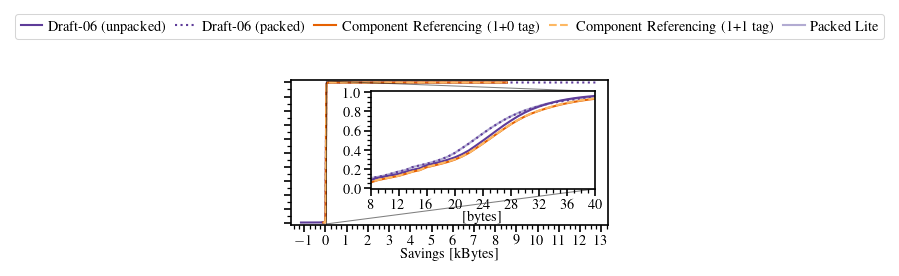

In [12]:
SLIDE_VERSION = False  # set to true for styling for slide set
ONLY_PAPER = True      # set to False to plot with filters based message types and datasets
# LABEL_YTICKS = True    # set to False if you want to omit the labels of the y-axis (like in the paper)
LABEL_YTICKS = False

for datasets_name, datasets in [("all", None), ("iot", ["yourthings", "iotfinder", "moniotr"]), ("tranco", ["tranco"]), ("oarc-ditl", ["DITL-20240409"])]:
    for prots_name, prots in [("", None), ("-wo_mdns", ["dns"])]:
        for qtype in [None, "A", "AAAA"]:
            if qtype is None:
                qtypes = None
                qtypes_name = ""
            else:
                qtypes = [qtype]
                qtypes_name = f"-{qtype}"

            filename = f"cbor+dns-name-comp-responses-woq-savings-{datasets_name}{prots_name}{qtypes_name}.pdf"
            IPython.display.display(
                IPython.display.Markdown(
                    f"#### Byte Savings [`{filename}`]"
                    f"({DNSCBOR_EVAL_DIR.relative_to(pathlib.Path.cwd()) / 'plots' / filename})"
                )
            )
            plot_cdf(
                [
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_plite_hist_savings_iot.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_classic_hist_savings_iot.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp7_hist_savings_iot.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp48_hist_savings_iot.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_plite_hist_savings_tranco.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_classic_hist_savings_tranco.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp7_hist_savings_tranco.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp48_hist_savings_tranco.csv",
                    # DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_plite_hist_savings_ditl_a-root_sfo8-a.csv",
                    # DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_classic_hist_savings_ditl_a-root_sfo8-a.csv",
                    # DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp7_hist_savings_ditl_a-root_sfo8-a.csv",
                    # DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp48_hist_savings_ditl_a-root_sfo8-a.csv",
                ],
                DNSCBOR_EVAL_DIR / "plots" / filename,
                "Savings [kBytes]",
                "bytes",
                datasets=datasets,
                prots=prots,
                msgs=["r"],
                qtypes=qtypes,
                with_question=[False],
                ignore_cols_with=[
                    "application/dns-message vs application/cbor+dns;packed=str-ref t7 byte savings",
                    "application/dns-message vs application/cbor+dns;packed=str-ref t48 byte savings",
                ],
                xlim=(-1.6 * 1024, 13.3 * 1024),
                xticks=numpy.arange(-1 * 1024, 14 * 1024, 1024),
                xaxis_formatter=matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x // 1024}$"),
                xaxis_minor_locator=matplotlib.ticker.MultipleLocator(0.25 * 1024),
                yticks_show=LABEL_YTICKS,
                labels={
                    "Responses (w/o question) application/dns-message vs application/cbor+dns byte savings": "Draft-06 (unpacked)",
                    "Responses (w/o question) application/dns-message vs application/cbor+dns;packed=1 byte savings": "Draft-06 (packed)",
                    "Responses (w/o question) application/dns-message vs application/cbor+dns;packed=lite byte savings": "Packed Lite",
                    "Responses (w/o question) application/dns-message vs application/cbor+dns t7 byte savings": "Component Referencing (1+0 tag)",
                    "Responses (w/o question) application/dns-message vs application/cbor+dns t48 byte savings": "Component Referencing (1+1 tag)",
                },
                styles={
                    "Draft-06 (unpacked)": "C0",
                    "Draft-06 (packed)": "C0:",
                    "Packed Lite": "C3",
                    "Component Referencing (1+0 tag)": "C1",
                    "Component Referencing (1+1 tag)": "C2--",
                },
                legend_loc="upper center",
                legend_fontsize="x-small",
                inset_axes_params={
                    "bounds": [0.25, 0.25, 0.71, 0.67],
                    "xlim": (8, 40),
                    "xticks": numpy.arange(8, 41, 4),
                    "ylim": (-0.01, 1.01),
                    "yticks": numpy.arange(0.0, 1.1, 0.2),
                    "xlabel": "[bytes]",
                    "xminor_locator": matplotlib.ticker.MultipleLocator(1),
                    "yminor_locator": matplotlib.ticker.MultipleLocator(0.05),
                },
                color_cycler=["#5e3c99", "#e66101", "#fdb863", "#b2abd2"],
                legend_order=["Draft-06 (unpacked)", "Draft-06 (packed)", "Component Referencing (1+0 tag)", "Component Referencing (1+1 tag)", "Packed Lite"],
                stylesheet="column_ieeetran" if not SLIDE_VERSION else "fullslide",
                figsize_factor=(2 / 3, 4 / 8),
                plot_label="Responses (w/o question)" if SLIDE_VERSION else None,
            )
            if ONLY_PAPER:
                break
        if ONLY_PAPER:
            break
    if ONLY_PAPER:
        break

### Responses (w/ question section)

#### Gain [`cbor+dns-name-comp-responses-wq-gain-all.pdf`](04_cbor4dns_eval/plots/cbor+dns-name-comp-responses-wq-gain-all.pdf)

,size [#],mean [%],std [%],min [%],median [%],max [%]
Packed Lite,2088333,17.8,29.8,-47.2,24.1,49.2
Draft-06 (unpacked),2088333,-32.8,45.3,-216.8,23.8,47.8
Draft-06 (packed),2088333,34.3,24.1,-47.2,23.7,52.4
Component Referencing (1+0 tag),2088333,27.2,29.2,-44.9,28.5,52.6
Component Referencing (1+1 tag),2088333,22.4,32.8,-44.9,26.9,50.0


\begin{tabular}{lrrrrrr}
\toprule
 & size [\#] & mean [\%] & std [\%] & min [\%] & median [\%] & max [\%] \\
\midrule
Packed Lite & 2088333 & 17.8 & 29.8 & -47.2 & 24.1 & 49.2 \\
Draft-06 (unpacked) & 2088333 & -32.8 & 45.3 & -216.8 & 23.8 & 47.8 \\
Draft-06 (packed) & 2088333 & 34.3 & 24.1 & -47.2 & 23.7 & 52.4 \\
Component Referencing (1+0 tag) & 2088333 & 27.2 & 29.2 & -44.9 & 28.5 & 52.6 \\
Component Referencing (1+1 tag) & 2088333 & 22.4 & 32.8 & -44.9 & 26.9 & 50.0 \\
\bottomrule
\end{tabular}



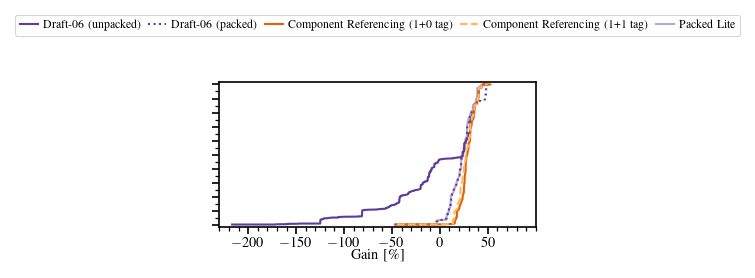

In [13]:
SLIDE_VERSION = False  # set to true for styling for slide set
ONLY_PAPER = True      # set to False to plot with filters based message types and datasets
# LABEL_YTICKS = True    # set to False if you want to omit the labels of the y-axis (like in the paper)
LABEL_YTICKS = False

for datasets_name, datasets in [("all", None), ("iot", ["yourthings", "iotfinder", "moniotr"]), ("tranco", ["tranco"]), ("oarc-ditl", ["DITL-20240409"])]:
    for prots_name, prots in [("", None), ("-wo_mdns", ["dns"])]:
        for qtype in [None, "A", "AAAA"]:
            if qtype is None:
                qtypes = None
                qtypes_name = ""
            else:
                qtypes = [qtype]
                qtypes_name = f"-{qtype}"

            filename = f"cbor+dns-name-comp-responses-wq-gain-{datasets_name}{prots_name}{qtypes_name}.pdf"
            IPython.display.display(
                IPython.display.Markdown(
                    f"#### Gain [`{filename}`]"
                    f"({DNSCBOR_EVAL_DIR.relative_to(pathlib.Path.cwd()) / 'plots' / filename})"
                )
            )
            plot_cdf(
                [
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_plite_hist_gain_iot.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_classic_hist_gain_iot.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp7_hist_gain_iot.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp48_hist_gain_iot.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_plite_hist_gain_tranco.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_classic_hist_gain_tranco.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp7_hist_gain_tranco.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp48_hist_gain_tranco.csv",
                    # DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_plite_hist_gain_ditl_a-root_sfo8-a.csv",
                    # DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_classic_hist_gain_ditl_a-root_sfo8-a.csv",
                    # DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp7_hist_gain_ditl_a-root_sfo8-a.csv",
                    # DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp48_hist_gain_ditl_a-root_sfo8-a.csv",
                ],
                DNSCBOR_EVAL_DIR / "plots" / filename,
                r"Gain [\%]",
                "%",
                lambda x: x * 100,
                datasets=datasets,
                prots=prots,
                msgs=["r"],
                qtypes=qtypes,
                with_question=[True],
                ignore_cols_with=[
                    "application/dns-message vs application/cbor+dns;packed=str-ref t7 gain",
                    "application/dns-message vs application/cbor+dns;packed=str-ref t48 gain",
                ],
                xlim=(-2.3, 1.0),
                xticks=numpy.arange(-2.0, 1.0, 0.5),
                xaxis_formatter=matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x * 100:0.0f}$"),
                xaxis_minor_locator=matplotlib.ticker.MultipleLocator(0.1),
                yticks_show=LABEL_YTICKS,
                labels={
                    "Responses (w/ question) application/dns-message vs application/cbor+dns gain": "Draft-06 (unpacked)",
                    "Responses (w/ question) application/dns-message vs application/cbor+dns;packed=1 gain": "Draft-06 (packed)",
                    "Responses (w/ question) application/dns-message vs application/cbor+dns;packed=lite gain": "Packed Lite",
                    "Responses (w/ question) application/dns-message vs application/cbor+dns t7 gain": "Component Referencing (1+0 tag)",
                    "Responses (w/ question) application/dns-message vs application/cbor+dns t48 gain": "Component Referencing (1+1 tag)",
                },
                styles={
                    "Draft-06 (unpacked)": "C0",
                    "Draft-06 (packed)": "C0:",
                    "Packed Lite": "C3",
                    "Component Referencing (1+0 tag)": "C1",
                    "Component Referencing (1+1 tag)": "C2--",
                },
                legend_loc="upper center",
                legend_order=["Draft-06 (unpacked)", "Draft-06 (packed)", "Component Referencing (1+0 tag)", "Component Referencing (1+1 tag)", "Packed Lite"],
                color_cycler=["#5e3c99", "#e66101", "#fdb863", "#b2abd2"],
                stylesheet="column_ieeetran" if not SLIDE_VERSION else "fullslide",
                figsize_factor=(2 / 3, 4 / 8),
                plot_label="Responses (w/ question)" if SLIDE_VERSION else None,
            )
            if ONLY_PAPER:
                break
        if ONLY_PAPER:
            break
    if ONLY_PAPER:
        break

#### Byte Savings [`cbor+dns-name-comp-responses-wq-savings-all.pdf`](04_cbor4dns_eval/plots/cbor+dns-name-comp-responses-wq-savings-all.pdf)

,size [#],mean [bytes],std [bytes],min [bytes],median [bytes],max [bytes]
Packed Lite,2088333,27.0,35.0,-42,17,203
Draft-06 (unpacked),2088333,-392.0,38.0,-760,15,110
Draft-06 (packed),2088333,64.0,50.0,-41,17,260
Component Referencing (1+0 tag),2088333,42.0,58.0,-39,24,226
Component Referencing (1+1 tag),2088333,27.0,38.0,-39,22,195


\begin{tabular}{lrrrrrr}
\toprule
 & size [\#] & mean [bytes] & std [bytes] & min [bytes] & median [bytes] & max [bytes] \\
\midrule
Packed Lite & 2088333 & 27.0 & 35.0 & -42 & 17 & 203 \\
Draft-06 (unpacked) & 2088333 & -392.0 & 38.0 & -760 & 15 & 110 \\
Draft-06 (packed) & 2088333 & 64.0 & 50.0 & -41 & 17 & 260 \\
Component Referencing (1+0 tag) & 2088333 & 42.0 & 58.0 & -39 & 24 & 226 \\
Component Referencing (1+1 tag) & 2088333 & 27.0 & 38.0 & -39 & 22 & 195 \\
\bottomrule
\end{tabular}



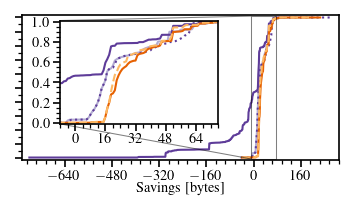

In [14]:
SLIDE_VERSION = False  # set to true for styling for slide set
ONLY_PAPER = True      # set to False to plot with filters based message types and datasets
# LABEL_YTICKS = True    # set to False if you want to omit the labels of the y-axis (like in the paper)
LABEL_YTICKS = False

for datasets_name, datasets in [("all", None), ("iot", ["yourthings", "iotfinder", "moniotr"]), ("tranco", ["tranco"]), ("oarc-ditl", ["DITL-20240409"])]:
    for prots_name, prots in [("", None), ("-wo_mdns", ["dns"])]:
        for qtype in [None, "A", "AAAA"]:
            if qtype is None:
                qtypes = None
                qtypes_name = ""
            else:
                qtypes = [qtype]
                qtypes_name = f"-{qtype}"

            filename = f"cbor+dns-name-comp-responses-wq-savings-{datasets_name}{prots_name}{qtypes_name}.pdf"
            IPython.display.display(
                IPython.display.Markdown(
                    f"#### Byte Savings [`{filename}`]"
                    f"({DNSCBOR_EVAL_DIR.relative_to(pathlib.Path.cwd()) / 'plots' / filename})"
                )
            )
            plot_cdf(
                [
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_plite_hist_savings_iot.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_classic_hist_savings_iot.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp7_hist_savings_iot.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp48_hist_savings_iot.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_plite_hist_savings_tranco.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_classic_hist_savings_tranco.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp7_hist_savings_tranco.csv",
                    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp48_hist_savings_tranco.csv",
                    # DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_plite_hist_savings_ditl_a-root_sfo8-a.csv",
                    # DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_classic_hist_savings_ditl_a-root_sfo8-a.csv",
                    # DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp7_hist_savings_ditl_a-root_sfo8-a.csv",
                    # DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_name_comp48_hist_savings_ditl_a-root_sfo8-a.csv",
                ],
                DNSCBOR_EVAL_DIR / "plots" / filename,
                "Savings [bytes]",
                "bytes",
                datasets=datasets,
                prots=prots,
                msgs=["r"],
                qtypes=qtypes,
                with_question=[True],
                ignore_cols_with=[
                    "application/dns-message vs application/cbor+dns;packed=str-ref t7 byte savings",
                    "application/dns-message vs application/cbor+dns;packed=str-ref t48 byte savings",
                ],
                xlim=(-784, 288),
                xticks=numpy.arange(-640, 289, 160),
                xaxis_minor_locator=matplotlib.ticker.MultipleLocator(32),
                yticks_show=LABEL_YTICKS,
                labels={
                    "Responses (w/ question) application/dns-message vs application/cbor+dns byte savings": "Draft-06 (unpacked)",
                    "Responses (w/ question) application/dns-message vs application/cbor+dns;packed=1 byte savings": "Draft-06 (packed)",
                    "Responses (w/ question) application/dns-message vs application/cbor+dns;packed=lite byte savings": "Packed Lite",
                    "Responses (w/ question) application/dns-message vs application/cbor+dns t7 byte savings": "Component Referencing (1+0 tag)",
                    "Responses (w/ question) application/dns-message vs application/cbor+dns t48 byte savings": "Component Referencing (1+1 tag)",
                },
                styles={
                    "Draft-06 (unpacked)": "C0",
                    "Draft-06 (packed)": "C0:",
                    "Packed Lite": "C3",
                    "Component Referencing (1+0 tag)": "C1",
                    "Component Referencing (1+1 tag)": "C2--",
                },
                legend_order=["Draft-06 (unpacked)", "Draft-06 (packed)", "Component Referencing (1+0 tag)", "Component Referencing (1+1 tag)", "Packed Lite"],                
                inset_axes_params={
                    "bounds": [0.12, 0.25, 0.50, 0.71],
                    "xlim": (-8, 76),
                    "xticks": numpy.arange(0, 76, 16),
                    "ylim": (-0.01, 1.01),
                    "yticks": numpy.arange(0.0, 1.1, 0.2),
                    "xminor_locator": matplotlib.ticker.MultipleLocator(4),
                    "yminor_locator": matplotlib.ticker.MultipleLocator(0.05),
                },
                color_cycler=["#5e3c99", "#e66101", "#fdb863", "#b2abd2"],
                stylesheet="column_ieeetran" if not SLIDE_VERSION else "fullslide",
                figsize_factor=(2 / 3, 4 / 8),
                plot_label="Responses (w/ question)" if SLIDE_VERSION else None,
            )
            if ONLY_PAPER:
                break
        if ONLY_PAPER:
            break
    if ONLY_PAPER:
        break

# Potentials for Optimization by Sharing Common IP Prefixes and Name Suffixes

Here, we generate the plots and data presented in Section IV.C, “Potentials for Optimization by Sharing Common IP Prefixes and Name Suffixes”, of our paper.

## Prepare Datasets

This requires `dns_names_slds_hist_categories_datasets.csv.gz` available in our `04_cbor4dns_eval.tar.xz` dataset on Zenodo. We provide parquet files in the Git repo (which we generate here) to execute the following cells without that file.

In [15]:
THRESHOLDS = {
    "suffix": 0.02,
    "category": 0.003,
}


def generate_top_100(lf, column):
    for dataset in ["all", "iot", "tranco", "secspider", "tls"]:
        filter = polars.col("dataset").is_not_null()
        if dataset != "all":
            filter &= (polars.col("dataset") == dataset)
    
        occs = lf.filter(filter).group_by(column).agg(
            polars.col("occurrences").sum()
        ).with_columns(
            ratio=polars.col("occurrences") / polars.col("occurrences").sum()
        ).sort(
            "occurrences",
            descending=True,
        )
        top_100 = occs.head(100).collect()
        
        top_100.write_parquet(
            DNSCBOR_EVAL_DIR / "output_datasets" / f"dns_names_slds_{column}_top100_{dataset}.parquet",
            compression="zstd",
            compression_level=22,
        )
        top_100.to_pandas().set_index(column).to_latex(
            DNSCBOR_EVAL_DIR / "output_datasets" / f"dns_names_slds_{column}_top100_{dataset}.tex",
        )
        del top_100

def summarize_by_column(
    lf,
    column,
    threshold,
    level_name="publicsuffixes",
    level=None,
    others_label="Others",
):
    summary = polars.concat(
        [
            lf.select(
                ["level", "dataset", column, "occurrences"]
            ).group_by(
                ["level", "dataset", column]
            ).sum(),
            lf.select(
                ["level", column, "occurrences"]
            ).group_by(
                ["level", column]
            ).sum().with_columns(
                polars.lit("all").alias("dataset")
            ).select(
                "level",
                "dataset",
                polars.exclude(["level", "dataset"]),
            ),
        ]
    ).with_columns(
        polars.col("occurrences").sum().over("dataset").alias("dataset_total")
    ).with_columns(
        ratio=polars.col("occurrences") / polars.col("dataset_total")
    ).select(polars.exclude("dataset_total")).sort(["level", "dataset", column])
    
    filter = polars.col("level").is_not_null()
    if level is not None:
        filter &= (polars.col("level") == level)

    included = summary.filter(
        polars.col("ratio") >= threshold
    ).select(column).collect()[column].unique().implode()

    distribution = polars.concat(
        [
            summary.filter(
                filter
                & polars.col(column).is_in(included)
            ).select(polars.exclude("level")).group_by(["dataset", column]).sum(),
            summary.filter(
                filter
                & ~polars.col(column).is_in(included)
            ).group_by("dataset").agg(
                polars.col("occurrences").sum(),
                polars.col("ratio").sum(),
            ).with_columns(
                polars.lit(others_label).alias(column)
            ).select(["dataset", column, "occurrences", "ratio"]),
        ]
    ).select(
        column,
        "dataset",
        "ratio",
    ).collect().pivot(
        "dataset",
        index=column
    ).sort(
        ["all", "iot", "tranco", "secspider", "tls"],
        descending=True,
    ).transpose(
        include_header=True,
        header_name="dataset",
        column_names=column,
    ).select(
        polars.col("dataset"),
        polars.col("No match"),
        polars.col("^Others.*$"),
        *(
            (
                [polars.col("Uncategorized")] if column == "category" else []
            ) + [
                polars.exclude(
                    "dataset",
                    "No match",
                    "^Others.*$",
                    *(["Uncategorized"] if column == "category"  else []),
                )
            ]
        ),
    ).with_columns(
        sort_key=polars.col("dataset").map_elements(
            lambda x: ["all", "iot", "tranco", "secspider", "tls"].index(x),
            return_dtype=polars.UInt8,
        )
    ).sort("sort_key").select(polars.exclude("sort_key"))

    distribution.write_parquet(
        DNSCBOR_EVAL_DIR / "output_datasets" / f"dns_names_slds_{column}_distribution_{level_name}.parquet",
        compression="zstd",
        compression_level=22,
    )
    del distribution
    del included

lf = polars.scan_csv(
    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_names_slds_hist_categories_datasets.csv.gz",
    schema_overrides={
        "occurrences": polars.UInt32,
        "category": polars.String,
    },
    # keep_default_na=False,
).with_columns(
    polars.col("category").fill_null("Uncategorized"),
    dataset=polars.when(
        polars.col("dataset").is_in(["yourthings", "moniotr", "iotfinder"])
    ).then(
        polars.lit("iot")
    ).otherwise(
        polars.col("dataset")
    ),
)

for column in ["suffix", "category"]:
    generate_top_100(lf, column)
    summarize_by_column(lf, column, THRESHOLDS[column])

## Public Suffixes in Matches

In [16]:
for dataset in ["all", "iot", "tranco", "secspider", "tls"]:
    top_100 = polars.read_parquet(
        DNSCBOR_EVAL_DIR / "output_datasets" / f"dns_names_slds_suffix_top100_{dataset}.parquet"
    ).head(100)
    IPython.display.display(
        IPython.display.Markdown(
            f"### {dataset} (Top {top_100.shape[0]}, "
            f"Top {top_100['ratio'].sum() * 100:0.1f}% "
            f"of {numpy.round(top_100.shape[0] / top_100['ratio'].sum()):0.0f})"
        )
    )
    with polars.Config(tbl_rows=100):
        display(top_100)

### all (Top 100, Top 92.4% of 108)

suffix,occurrences,ratio
str,u32,f64
"""No match""",1274408987,0.32493
"""com""",1250544795,0.318846
"""googledomains.com""",435996896,0.111164
"""nl""",119125622,0.030373
"""se""",50009201,0.012751
"""ovh.net""",40790063,0.0104
"""cz""",32874474,0.008382
"""one.com""",31533630,0.00804
"""cloudflare.com""",30453495,0.007765


### iot (Top 100, Top 98.4% of 102)

suffix,occurrences,ratio
str,u32,f64
"""netflix.com""",14367037,0.157248
"""No match""",12421736,0.135957
"""google.com""",11924042,0.130509
"""com""",10978973,0.120166
"""hichina.com""",8635480,0.094516
"""ring.com""",4229971,0.046297
"""smartthings.com""",2676351,0.029293
"""canaryis.com""",2429077,0.026586
"""august.com""",1579592,0.017289


### tranco (Top 100, Top 62.7% of 160)

suffix,occurrences,ratio
str,u32,f64
"""No match""",101690438,0.319749
"""com""",49979551,0.157152
"""cloudflare.com""",7372042,0.02318
"""ru""",4433595,0.013941
"""jp""",4298588,0.013516
"""net""",2199704,0.006917
"""de""",2053393,0.006457
"""kz""",1919869,0.006037
"""ticbrasil.com.br""",1057818,0.003326


### secspider (Top 100, Top 96.8% of 103)

suffix,occurrences,ratio
str,u32,f64
"""com""",1169906414,0.342994
"""No match""",1124403956,0.329653
"""googledomains.com""",435459588,0.127668
"""nl""",117934110,0.034576
"""se""",49740058,0.014583
"""ovh.net""",40454212,0.01186
"""cz""",32395954,0.009498
"""one.com""",31477550,0.009229
"""br""",22093374,0.006477


### tls (Top 100, Top 68.7% of 146)

suffix,occurrences,ratio
str,u32,f64
"""No match""",35892857,0.352455
"""com""",19679857,0.193249
"""cloudflare.com""",2775777,0.027257
"""net""",1629373,0.016
"""ru""",1579850,0.015514
"""de""",664371,0.006524
"""cloudflare.net""",590648,0.0058
"""nl""",572579,0.005623
"""wixdns.net""",455322,0.004471


### Plot Suffix Shares

dataset,No match,Others,com,googledomains.com,nl,cloudflare.com,netflix.com,google.com,hichina.com,ring.com,smartthings.com,canaryis.com
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""all""",0.32493,0.195155,0.318846,0.111164,0.030373,0.007765,0.003663,0.00335,0.002374,0.001079,0.000682,0.000619
"""iot""",0.135957,0.259416,0.120166,null,null,0.000012,0.157248,0.130509,0.094516,0.046297,0.029293,0.026586
"""tranco""",0.319749,0.494944,0.157152,0.001689,0.001946,0.02318,1.5093e-7,0.00006,0.001278,2.3582e-7,1.5407e-7,7.2320e-8
"""secspider""",0.329653,0.15877,0.342994,0.127668,0.034576,0.005953,1.1727e-9,0.000331,0.000055,null,null,null
"""tls""",0.352455,0.419934,0.193249,0.000001,0.005623,0.027257,0.000002,0.000678,0.000802,5.8918e-8,8.8377e-8,null


#### [Matching Domain Name Suffix (12 Suffixes)](04_cbor4dns_eval/plots/dns_names_publicsuffixes.pdf)

<Figure size 640x480 with 0 Axes>

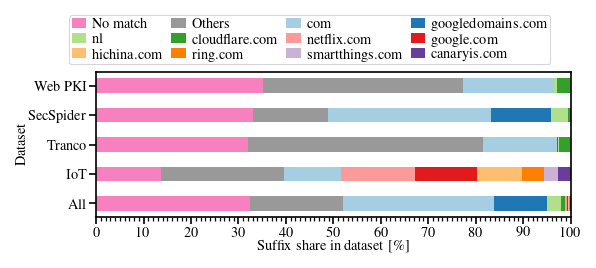

In [17]:
TITLES = {
    "publicsuffixes": "Domain Name Suffix",
    "tlds": "TLD",
    "slds": "SLD",
}

level_name = "publicsuffixes"

matplotlib.pyplot.clf()
matplotlib.style.use(pathlib.Path.cwd() / f"mlenders_column_ieeetran.mplstyle")
matplotlib.rcParams["figure.figsize"] = (
    matplotlib.rcParams["figure.figsize"][0],
    matplotlib.rcParams["figure.figsize"][1] * 4 / 8
)
matplotlib.rcParams["legend.labelspacing"] = 0.15
matplotlib.rcParams["legend.borderpad"] = 0.2
matplotlib.pyplot.rc(
    "axes",
    prop_cycle=cycler.cycler(
        color=["#f781bf", "#999999"] + list(matplotlib.colormaps["Paired"].colors)
    )
)

fig = matplotlib.pyplot.figure(
    figsize=matplotlib.rcParams["figure.figsize"],
    dpi=150,
)
ax = matplotlib.pyplot.gca()

distribution = polars.read_parquet(
    DNSCBOR_EVAL_DIR / "output_datasets" / f"dns_names_slds_suffix_distribution_{level_name}.parquet"
)
IPython.display.display(distribution)

bottom = numpy.zeros(distribution.shape[0])

for column in distribution.columns[1:]:
    matplotlib.pyplot.barh(
        distribution[distribution.columns[0]],
        distribution[column].fill_null(0),
        height=0.5,
        left=bottom,
        label=column,
    )
    bottom += distribution[column].fill_null(0).to_numpy()

ax.xaxis.set_major_formatter(
    matplotlib.ticker.PercentFormatter(1, symbol="", decimals=0, is_latex=True)
)
ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.01))
ax.set_ylabel("Dataset")
ax.set_yticks(range(0, 5), ["All", "IoT", "Tranco", "SecSpider", "Web PKI"])
ax.set_xlabel(r"Suffix share in dataset [\%]")
ax.set_xticks(numpy.arange(0, 1.1, 0.1))
ax.set_xlim((0, 1.0))

def flip(items, ncol):
    return itertools.chain(*[items[i::ncol] for i in range(ncol)])

handles, labels = ax.get_legend_handles_labels()
NCOL = 4
ax.legend(
    handles=flip(handles, NCOL),
    labels=flip(labels, NCOL),
    ncol=NCOL,
    loc="lower center",
    bbox_to_anchor=(0.45, 1)
)
filename = DNSCBOR_EVAL_DIR / "plots" / f"dns_names_{level_name}.pdf"
matplotlib.pyplot.savefig(
    filename,
    bbox_inches="tight",
    pad_inches=0.01,
)
IPython.display.display(
    IPython.display.Markdown(
        f"#### [Matching {TITLES[level_name]} "
        f"({len(distribution.columns) - 1} Suffixes)]"
        f"({str(filename.relative_to(pathlib.Path.cwd()))})"
    )
)
matplotlib.pyplot.show()

## Categories of Public Suffixes in Matches

In [18]:
for dataset in ["all", "iot", "tranco", "secspider", "tls"]:
    top_100 = polars.read_parquet(
        DNSCBOR_EVAL_DIR / "output_datasets" / f"dns_names_slds_category_top100_{dataset}.parquet"
    ).head(100)
    IPython.display.display(
        IPython.display.Markdown(
            f"### {dataset} (Top {top_100.shape[0]}, "
            f"Top {top_100['ratio'].sum() * 100:0.1f}% "
            f"of {numpy.round(top_100.shape[0] / top_100['ratio'].sum()):0.0f})"
        )
    )
    with polars.Config(tbl_rows=100):
        display(top_100)

### all (Top 100, Top 100.0% of 100)

category,occurrences,ratio
str,u32,f64
"""tld""",1583546072,0.403749
"""No match""",1274408987,0.32493
"""Uncategorized""",534406462,0.136255
"""google""",450190192,0.114783
"""cloudflare""",31131170,0.007937
"""netflix""",14404680,0.003673
"""alibaba""",10146138,0.002587
"""amazon""",9026320,0.002301
"""gandi""",2429104,0.000619


### iot (Top 94, Top 100.0% of 94)

category,occurrences,ratio
str,u32,f64
"""Uncategorized""",16702024,0.182805
"""netflix""",14396808,0.157574
"""google""",12892999,0.141115
"""No match""",12421736,0.135957
"""tld""",12270146,0.134298
"""alibaba""",8800521,0.096322
"""amazon""",8574148,0.093845
"""meta""",1543462,0.016893
"""roku""",934573,0.010229


### tranco (Top 100, Top 100.0% of 100)

category,occurrences,ratio
str,u32,f64
"""Uncategorized""",124804862,0.392428
"""No match""",101690438,0.319749
"""tld""",80524960,0.253197
"""cloudflare""",7395936,0.023255
"""alibaba""",862714,0.002713
"""google""",589754,0.001854
"""akamai""",501351,0.001576
"""amazon""",203846,0.000641
"""tencent""",177312,0.000558


### secspider (Top 100, Top 100.0% of 100)

category,occurrences,ratio
str,u32,f64
"""tld""",1462701628,0.428836
"""No match""",1124403956,0.329653
"""google""",436633026,0.128012
"""Uncategorized""",359762066,0.105475
"""cloudflare""",20305478,0.005953
"""gandi""",2212684,0.000649
"""wordpress""",1219690,0.000358
"""akamai""",785198,0.00023
"""microsoft""",771634,0.000226


### tls (Top 100, Top 100.0% of 100)

category,occurrences,ratio
str,u32,f64
"""No match""",35892857,0.352455
"""Uncategorized""",33137510,0.325398
"""tld""",28049338,0.275434
"""cloudflare""",3368868,0.033081
"""akamai""",218643,0.002147
"""webflow""",161823,0.001589
"""amazon""",152990,0.001502
"""shopify""",143368,0.001408
"""fastly""",134920,0.001325


### Plot Category Share

dataset,No match,Others,Uncategorized,tld,google,cloudflare,netflix,alibaba,amazon,akamai,meta,microsoft,roku,apple,verizon
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""all""",0.32493,0.00195,0.136255,0.403749,0.114783,0.007937,0.003673,0.002587,0.002301,0.000605,0.000399,0.000363,0.000238,0.000128,0.000101
"""iot""",0.135957,0.006545,0.182805,0.134298,0.141115,0.000666,0.157574,0.096322,0.093845,0.009485,0.016893,0.005006,0.010229,0.00535,0.003911
"""tranco""",0.319749,0.004104,0.392428,0.253197,0.001854,0.023255,0.000018,0.002713,0.000641,0.001576,0.000029,0.000357,0.000001,0.000026,0.000051
"""secspider""",0.329653,0.001467,0.105475,0.428836,0.128012,0.005953,5.6232e-7,0.00011,0.000028,0.00023,9.6456e-7,0.000226,null,0.000002,0.000005
"""tls""",0.352455,0.007275,0.325398,0.275434,0.000731,0.033081,0.000003,0.001043,0.001502,0.002147,0.000069,0.000811,4.8116e-7,0.000013,0.000039


#### [Category of Matching Domain Name Suffix (15 Categories)](04_cbor4dns_eval/plots/dns_names_publicsuffixes.pdf)

<Figure size 408.05x126.094 with 0 Axes>

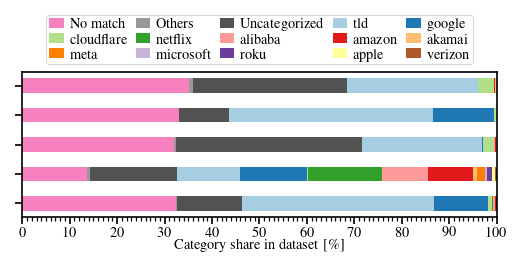

In [19]:
TITLES = {
    "publicsuffixes": "Domain Name Suffix",
    "tlds": "TLD",
    "slds": "SLD",
}

level_name = "publicsuffixes"

matplotlib.pyplot.clf()
matplotlib.style.use(pathlib.Path.cwd() / f"mlenders_column_ieeetran.mplstyle")
matplotlib.rcParams["figure.figsize"] = (
    matplotlib.rcParams["figure.figsize"][0],
    matplotlib.rcParams["figure.figsize"][1] * 4 / 8
)
matplotlib.rcParams["legend.labelspacing"] = 0.15
matplotlib.rcParams["legend.borderpad"] = 0.2
matplotlib.pyplot.rc(
    "axes",
    prop_cycle=cycler.cycler(
        color=["#f781bf", "#999999", "#525252"] + list(
            matplotlib.colormaps["Paired"].colors
        )
    )
)

fig = matplotlib.pyplot.figure(
    figsize=matplotlib.rcParams["figure.figsize"],
    dpi=150,
)
ax = matplotlib.pyplot.gca()

distribution = polars.read_parquet(
    DNSCBOR_EVAL_DIR / "output_datasets" / f"dns_names_slds_category_distribution_{level_name}.parquet"
)
IPython.display.display(distribution)

bottom = numpy.zeros(distribution.shape[0])

for column in distribution.columns[1:]:
    matplotlib.pyplot.barh(
        distribution[distribution.columns[0]],
        distribution[column].fill_null(0),
        height=0.5,
        left=bottom,
        label=column,
    )
    bottom += distribution[column].fill_null(0).to_numpy()

ax.xaxis.set_major_formatter(
    matplotlib.ticker.PercentFormatter(1, symbol="", decimals=0, is_latex=True)
)
ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.01))
# ax.set_ylabel("Dataset")
# ax.set_yticks(range(0, 5), ["All", "IoT", "Tranco", "SecSpider", "Web PKI"])
y_label = ax.axes.get_yaxis().get_label()
y_label.set_visible(False)
ax.set_yticklabels([])
ax.set_xlabel(r"Category share in dataset [\%]")
ax.set_xticks(numpy.arange(0, 1.1, 0.1))
ax.set_xlim((0, 1.0))

def flip(items, ncol):
    return itertools.chain(*[items[i::ncol] for i in range(ncol)])

handles, labels = ax.get_legend_handles_labels()
NCOL = 5
ax.legend(
    handles=flip(handles, NCOL),
    labels=flip(labels, NCOL),
    ncol=NCOL,
    loc="lower center",
    bbox_to_anchor=(0.5, 1)
)
filename = DNSCBOR_EVAL_DIR / "plots" / f"dns_names_{level_name}.pdf"
matplotlib.pyplot.savefig(
    filename,
    bbox_inches="tight",
    pad_inches=0.01,
)
IPython.display.display(
    IPython.display.Markdown(
        f"#### [Category of Matching {TITLES[level_name]} "
        f"({len(distribution.columns) - 1} Categories)]"
        f"({str(filename.relative_to(pathlib.Path.cwd()))})"
    )
)
matplotlib.pyplot.show()

## Violin Plotting Definition

In [20]:
def aggregate_name_hist(
    files,
    metric,
    datasets: list[str] = None,
    prots: list[str] = ["dns", "mdns"],
    msgs: list[str] = None,
    qtypes: list[str] = None,
    ignore_same_names=False,
):
    df = pandas.DataFrame()
    for file in files:
        df = pandas.concat(
            [df, pandas.read_csv(file, dtype={"qtype": "str"})]
        )
    filter = ~df["dataset"].isna()
    if datasets is not None:
        filter &= df["dataset"].isin(datasets)
    if prots is not None:
        filter &= df["prot"].isin(prots)
    if msgs is not None:
        filter &= df["msg"].isin(msgs)
    if qtypes is not None:
        filter &= df["qtype"].isin(qtypes)
    # print(df.groupby("qtype")["csb"].count().index)
    df = df[filter]
    val = df.groupby("bytes")[metric].sum()
    norm = df[metric].sum()
    if ignore_same_names:
        if metric == "csb":
            same_names = df[["bytes", "same_names_csb"]]
            val -= same_names.groupby("bytes")["same_names_csb"].sum()
            norm -= same_names["same_names_csb"].sum()
        if metric == "ccsb":
            same_names = df[["bytes", "same_name_ccsb"]]
            val -= same_names.groupby("bytes")["same_name_ccsb"].sum()
            norm -= same_names["same_name_ccsb"].sum()
    hist = val / norm
    if hist.count():
        return norm, hist.reindex(numpy.arange(hist.index.min(), hist.index.max() + 1)).to_frame()
    else:
        return norm, hist.to_frame()


def aggregate_addr_hist(
    files,
    ip,
    datasets: list[str] = None,
    prots: list[str] = ["dns", "mdns"],
    msgs: list[str] = None,
    qtypes: list[str] = None,
    ignore_same_addrs=False,
):
    df = pandas.DataFrame()
    for file in files:
        df = pandas.concat(
            [df, pandas.read_csv(file, dtype={"qtype": "str"})]
        )
    filter = df["ip"] == ip
    if datasets is not None:
        filter &= df["dataset"].isin(datasets)
    if prots is not None:
        filter &= df["prot"].isin(prots)
    if msgs is not None:
        filter &= df["msg"].isin(msgs)
    if qtypes is not None:
        filter &= df["qtype"].isin(qtypes)
    #print(df.groupby("qtype")["cpb"].count().index)
    df = df[filter]
    if ignore_same_addrs:
        max_bytes = 4 if ip == "ipv4" else 16
        df = df[df["bytes"] < max_bytes]
    val = df.groupby("bytes")["cpb"].sum()
    norm = df["cpb"].sum()
    hist = val / norm
    if hist.count():
        return norm, hist.reindex(numpy.arange(hist.index.min(), hist.index.max() + 1)).to_frame()
    else:
        return norm, hist.to_frame()


def hist_quartiles(df, col):
    idx = [0.25, 0.5, 0.75]
    quartiles = []
    for quartile in idx:
        total = 0
        for value in sorted(df.index):
            total += df.loc[value, col]
            if total >= quartile:
                quartiles.append(value)
                break
    if not quartiles:
        quartiles.append(numpy.nan)
    while len(quartiles) < len(idx):
        quartiles.append(quartiles[-1])
    return quartiles



def hist_violin_stats(df, col):
    data = df[(~df[col].isna())][col]
    mean = numpy.average(data.index, weights=data)
    min = data[data != 0].index.min()
    max = data[data != 0].index.max()
    quartiles = hist_quartiles(df, col)
    return {
        "coords": list(data[data != 0].index),
        "vals": list(data[data != 0]),
        "mean": mean,
        "median": quartiles[1],
        "min": min,
        "max": max,
        "quantiles": quartiles,
    }


def plot_violin_stats(
    df, violin_stats, ylabel, output_name,
    yticks=None, ylim=None, figstyle=None, figsize_factor=None,
    set_ylabels=True, legend_ncol=3, legend_loc=None,
    legend_anchor=None, xticks_rotation=0,
    xticks_ha="center", xticks_va="top",
    yaxis_minor_locator=None, 
    inset_axes_params=None,
    indicate_inset_zoom_params={
        "edgecolor": "black",
        "linewidth": 0.5,
    },
    yscale=None,
):
    matplotlib.pyplot.gcf()
    if figstyle is None:
        figstyle = "column"
    if figsize_factor is None:
        figsize_factor = (1, 1)
    matplotlib.style.use(pathlib.Path.cwd() / f"mlenders_{figstyle}_ieeetran.mplstyle")
    matplotlib.rcParams["figure.figsize"] = (
        matplotlib.rcParams["figure.figsize"][0] * figsize_factor[0],
        matplotlib.rcParams["figure.figsize"][1] * figsize_factor[1],
    )
    matplotlib.rcParams["legend.labelspacing"] = 0.15
    matplotlib.rcParams["legend.borderpad"] = 0.2
    matplotlib.rcParams["xtick.labelsize"] = "xx-small"
    fig = matplotlib.pyplot.figure(
        figsize=matplotlib.rcParams["figure.figsize"],
        dpi=150,
    )
    ax = matplotlib.pyplot.gca()
    if inset_axes_params:
        axins_yminor_locator = inset_axes_params.pop("yminor_locator", None)
        axins = ax.inset_axes(**inset_axes_params)
        axs = [ax, axins]
    else:
        axins_yminor_locator = None
        axins = None
        axs = [ax]
    for a in axs:
        violin_plot = a.violin(
            [violin_stats[c] for c in df.columns if c in violin_stats],
            positions=[i for i, c in enumerate(df.columns) if c in violin_stats],
            showmeans=True,
            showmedians=True,
            widths=0.95,
        )
        for body in violin_plot["bodies"]:
            body.set_edgecolor("#222222")
            body.set_facecolor("#dddddd")
            body.set_linewidth(0.125)
            body.set_alpha(0.50)
        violin_plot["cquantiles"].set_edgecolor("#fdb863")
        violin_plot["cquantiles"].set_linewidth(0.25)
        violin_plot["cquantiles"].set_zorder(10)
        violin_plot["cmedians"].set_edgecolor("#e66101")
        violin_plot["cmedians"].set_linewidth(0.25)
        if "median" in violin_stats and not numpy.isnan(violin_stats["median"]):
            violin_plot["cmedians"].set_segments(
                [seg + numpy.array([[1/30, 0], [-1/30, 0]]) for seg in violin_plot["cmedians"].get_segments()]
            )
        violin_plot["cmedians"].set_zorder(20)
        violin_plot["cmeans"].set_edgecolor("#b2abd2")
        violin_plot["cmeans"].set_linewidth(0.25)
        violin_plot["cmeans"].set_zorder(30)
        violin_plot["cmeans"].set_segments(
            [seg + numpy.array([[2/30, 0], [-2/30, 0]]) for seg in violin_plot["cmeans"].get_segments()]
        )
        violin_plot["cbars"].set_edgecolor("black")
        violin_plot["cbars"].set_linewidth(0.25)
        violin_plot["cmins"].set_edgecolor("black")
        violin_plot["cmins"].set_linewidth(0.25)
        violin_plot["cmaxes"].set_edgecolor("black")
        violin_plot["cmaxes"].set_linewidth(0.25)
    legend_lines = [
        matplotlib.lines.Line2D([0], [0], color="#b2abd2", linewidth=0.25),
        matplotlib.lines.Line2D([0], [0], color="#e66101", linewidth=0.25),
        matplotlib.lines.Line2D([0], [0], color="#fdb863", linewidth=0.25),
        matplotlib.lines.Line2D([0], [0], color="black", linewidth=0.25),
    ]
    ax.legend(legend_lines, ["Mean", "Median", "Quartiles", "Min/Max"], ncol=legend_ncol,
              loc=legend_loc, bbox_to_anchor=legend_anchor)
    
    ax.set_xlim((-0.5, len(df.columns) - 0.5))
    ax.set_xticks(
        range(len(df.columns)),
        df.columns,
        rotation=xticks_rotation,
        rotation_mode='anchor' if xticks_rotation != 0 else None,
        ha=xticks_ha,
        va=xticks_va
    )
    ax.set_xlabel("Queried record type")
    if yticks:
        ax.set_yticks(yticks)
    elif yscale is None:
        ax.set_yticks(range(5) if addr_type == "ipv4" else range(17))
    else:
        ax.set_yscale(yscale)
    if ylim:
        ax.set_ylim(ylim)
    elif yscale is None:
        ax.set_ylim((-0.1, 4.1) if addr_type == "ipv4" else (-0.4, 17.4))
    else:
        ax.set_yscale(yscale)
    if set_ylabels:
        ax.set_ylabel(ylabel)
    else:
        ax.set_yticklabels([])
    if yaxis_minor_locator:
        ax.yaxis.set_minor_locator(yaxis_minor_locator)
    
    if axins:
        if indicate_inset_zoom_params:
            connector_line_visibility = indicate_inset_zoom_params.pop("connector_line_visibility", [])
            _, connector_lines = ax.indicate_inset_zoom(axins, **indicate_inset_zoom_params)
            if connector_line_visibility:
                for i, visible in enumerate(connector_line_visibility):
                    if i >= len(connector_lines):
                        break
                    connector_lines[i].set(visible=visible)
                for i in range(len(connector_line_visibility), len(connector_lines)):
                    connector_lines[i].set(visible=False)
        axins.set_xticklabels([])
        if axins_yminor_locator:
            axins.yaxis.set_minor_locator(axins_yminor_locator)
    matplotlib.pyplot.savefig(
        output_name,
        bbox_inches="tight",
        pad_inches=0.01,
    )
    matplotlib.pyplot.show()

## Suffix Match Occurrences per Message

This section requires the cell under [Violin Plotting Definition](#Violin-Plotting-Definition) to be run.

### `dns_qr_names_hist_suffix_occs_all`

,mean,min,median,max,quartiles
All,3.716338,1,1,1057785,"[1, 1, 1]"
A,9.046693,1,1,1057785,"[1, 1, 1]"
AAAA,2.244093,1,1,655,"[1, 1, 1]"
DNSKEY,1.886474,1,1,5253,"[1, 1, 1]"
DS,2.727468,1,1,276,"[1, 1, 1]"
HTTPS,1.845866,1,1,564,"[1, 1, 1]"
NS,7.160788,1,1,271803,"[1, 1, 1]"
NSEC,1.831102,1,1,116,"[1, 1, 1]"
NSEC3,1.824056,1,1,116,"[1, 1, 1]"
PTR,1.874483,1,1,7452,"[1, 1, 1]"


<Figure size 640x480 with 0 Axes>

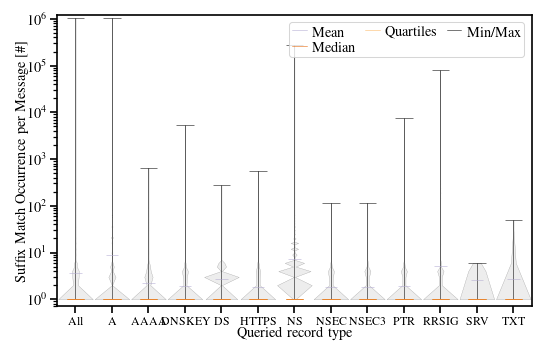

In [21]:
ONLY_ALL = True

for prot in ["dns", "mdns"]:
    for msgs in [["q", "r"], ["q"], ["r"]]:
        for dataset_name, dataset in [
            ("all", None),
            ("iot", ["yourthings", "iotfinder", "moniotr"]),
            ("tranco", ["tranco"])
        ]:
            violin_stats = {}
            df = pandas.DataFrame()
            for qtype in [None, "A", "AAAA", "CAA", "DNSKEY", "DS", "HTTPS", "NS", "NSEC", "NSEC3", "PTR", "RRSIG", "SOA", "SRV", "TLSA", "TXT"]:
                colname = qtype if qtype is not None else "All"
                tmp = pandas.read_csv(DNSCBOR_EVAL_DIR / "output_datasets" / "dns_names_hist_suffix_occs.csv.gz")
                tmp = tmp[(tmp["protocol"] == prot) & (tmp["msg"].isin(msgs))]
                if dataset is not None:
                    tmp = tmp[tmp["dataset"].isin(dataset)]
                if qtype is not None:
                    tmp = tmp[tmp["qtype"] == qtype]
                tmp = tmp.groupby(["occurrences"]).sum()["count"]
                if tmp.isna().all():
                    continue
                df[colname] = tmp
                violin_stats[colname] = hist_violin_stats(df, colname)
            if not violin_stats:
                continue
            filename = (
                f"dns{'_mdns' if prot == 'mdns' else ''}_{''.join(msgs)}_"
                f"names_hist_suffix_occs_{dataset_name}"
            )
            IPython.display.display(IPython.display.Markdown(f"### `{filename}`"))
            IPython.display.display(
                pandas.DataFrame(violin_stats).T[["mean", "min", "median", "max", "quantiles"]].rename(
                    columns={"quantiles": "quartiles"}
                )
            )
            plot_violin_stats(
                df,
                violin_stats,
                "Suffix Match Occurrence per Message " r"[\#]",
                DNSCBOR_EVAL_DIR / "plots" / f"{filename}.pdf",
                ylim=(0.70, 1.2e6),
                # yticks=range(0, 280, 50),
                yscale="log",
            )
            if ONLY_ALL:
                break
        if ONLY_ALL:
            break
    if ONLY_ALL:
        break

## Name Suffix Matches

This section requires the cell under [Violin Plotting Definition](#Violin-Plotting-Definition) to be run.

#### [`dns_r_names_csb_hist_all_w_same_name.pdf`](04_cbor4dns_eval/plots/dns_r_names_csb_hist_all_w_same_name.pdf)

,size,mean,min,median,max,quartiles
SRV,522,8.963602,4,10,15,"[4, 10, 14]"
TLSA,17393766,6.419172,0,4,102,"[0, 4, 12]"
SOA,21133546,6.255266,0,4,92,"[0, 4, 11]"
CAA,21632714,6.545328,0,4,92,"[0, 4, 12]"
HTTPS,22470679,5.39274,0,4,92,"[0, 4, 10]"
NSEC,23488807,5.854726,0,4,92,"[0, 4, 11]"
NSEC3,24217391,5.674782,0,4,92,"[0, 4, 10]"
DNSKEY,24783104,5.884319,0,4,92,"[0, 4, 11]"
PTR,25318760,5.753836,0,4,92,"[0, 4, 10]"
DS,25612152,2.365735,0,2,73,"[0, 2, 3]"


<Figure size 408.05x252.189 with 0 Axes>

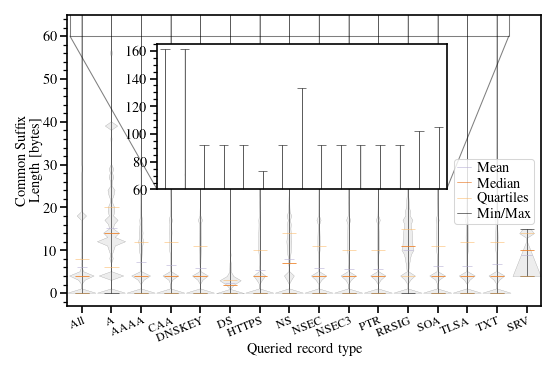

#### [`dns_r_names_ccsb_hist_all_w_same_name.pdf`](04_cbor4dns_eval/plots/dns_r_names_ccsb_hist_all_w_same_name.pdf)

,size,mean,min,median,max,quartiles
SRV,522,9.233716,4,11,15,"[4, 11, 15]"
TLSA,17393766,6.882734,1,4,103,"[1, 4, 12]"
SOA,21133546,6.779496,1,4,92,"[1, 4, 12]"
CAA,21632714,7.085351,1,4,92,"[1, 4, 13]"
HTTPS,22470679,5.992762,1,4,92,"[1, 4, 11]"
NSEC,23488807,6.34904,1,4,92,"[1, 4, 12]"
NSEC3,24217391,6.15749,1,4,92,"[1, 4, 11]"
DNSKEY,24783104,6.383177,1,4,92,"[1, 4, 12]"
PTR,25318760,6.237406,1,4,92,"[1, 4, 11]"
DS,25612152,3.049208,1,3,74,"[1, 3, 4]"


<Figure size 408.05x252.189 with 0 Axes>

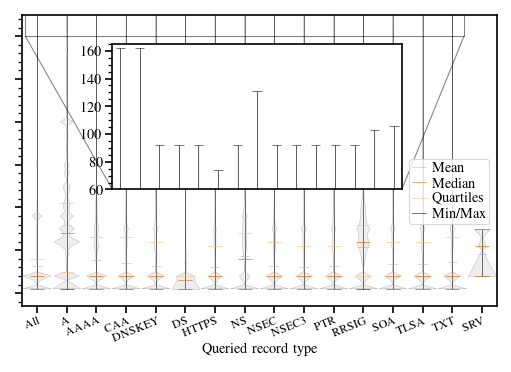

#### [`dns_r_names_csb_hist_soa_all_w_same_name.pdf`](04_cbor4dns_eval/plots/dns_r_names_csb_hist_soa_all_w_same_name.pdf)

,size,mean,min,median,max,quartiles
SRV,435,8.524138,4,4,15,"[4, 4, 14]"
NS,1180645,3.085906,0,2,67,"[0, 2, 4]"
A,2010521,3.228043,0,0,58,"[0, 0, 4]"
RRSIG,13216433,4.25732,0,3,92,"[0, 3, 4]"
TLSA,13642056,3.980903,0,3,92,"[0, 3, 4]"
CAA,14858874,3.906141,0,3,92,"[0, 3, 4]"
SOA,15131530,3.927757,0,3,92,"[0, 3, 4]"
HTTPS,16238547,3.818092,0,3,92,"[0, 3, 4]"
AAAA,16404106,3.777863,0,3,92,"[0, 3, 4]"
NSEC,18965975,4.02941,0,3,92,"[0, 3, 4]"


<Figure size 408.05x252.189 with 0 Axes>

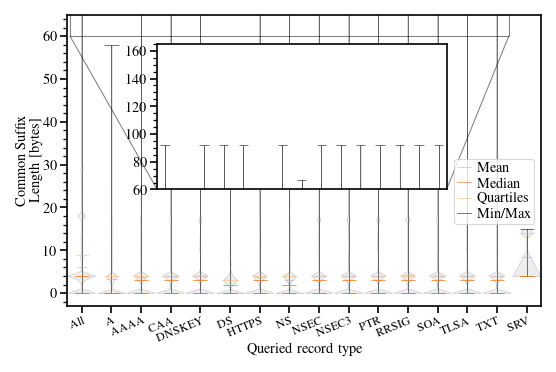

#### [`dns_r_names_ccsb_hist_soa_all_w_same_name.pdf`](04_cbor4dns_eval/plots/dns_r_names_ccsb_hist_soa_all_w_same_name.pdf)

,size,mean,min,median,max,quartiles
SRV,435,8.648276,4,4,15,"[4, 4, 15]"
NS,1180645,3.628345,1,3,68,"[1, 3, 4]"
A,2010521,3.736621,1,1,58,"[1, 1, 4]"
RRSIG,13216433,4.594209,1,3,92,"[1, 3, 4]"
TLSA,13642056,4.337571,1,3,92,"[1, 3, 4]"
CAA,14858874,4.299712,1,3,92,"[1, 3, 4]"
SOA,15131530,4.320745,1,3,92,"[1, 3, 4]"
HTTPS,16238547,4.289238,1,3,92,"[1, 3, 4]"
AAAA,16404106,4.240777,1,3,92,"[1, 3, 4]"
NSEC,18965975,4.41346,1,3,92,"[1, 3, 4]"


<Figure size 408.05x252.189 with 0 Axes>

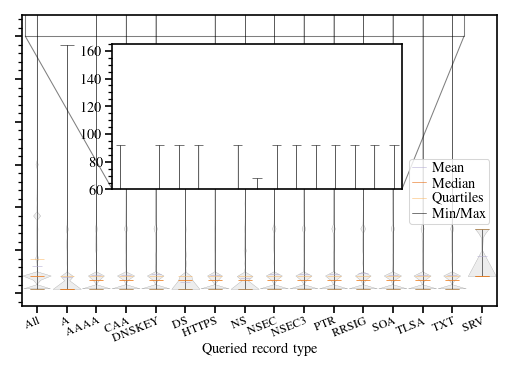

In [22]:
ONLY_PAPER = True      # set to False to plot with filters based message types and datasets

for prots in [["dns", "mdns"], ["dns"], ["mdns"], ["assoc"]]:
    for msgs in [["r"], ["q"]]:
        for soa in ["", "_soa"]:
            for dataset_name, dataset in [
                ("all", None),
                #("iot", ["yourthings", "iotfinder", "moniotr"]),
                #("secspider", ["secspider"]),
                #("tls", ["tls"]),
                #("tranco", ["tranco"])
            ]:
                for ignore_same_names in [False, True]:
                    for metric in ["csb", "ccsb"]:
                        if msgs == ["q"] and "mdns" not in prots:  # "q" queries do not contain multiple names
                            continue
                        violin_stats = {}
                        df = pandas.DataFrame()
                        for qtype in [None, "A", "AAAA", 
                                      "CAA", "DNSKEY", "DS", "HTTPS", "NS", "NSEC", "NSEC3",
                                      "PTR",
                                      "RRSIG",
                                      "SOA", 
                                      "TLSA",
                                      "TXT", "SRV"]:
                            colname = qtype if qtype is not None else "All"
                            size, df[colname] = aggregate_name_hist(
                                [
                                    DNSCBOR_EVAL_DIR / "output_datasets" / f"dns_names_hist{soa}_iot.csv",
                                    DNSCBOR_EVAL_DIR / "output_datasets" / f"dns_names_hist{soa}_webpki.csv",
                                    DNSCBOR_EVAL_DIR / "output_datasets" / f"dns_names_hist{soa}_secspider.csv",
                                    DNSCBOR_EVAL_DIR / "output_datasets" / f"dns_names_hist{soa}_tranco.csv",
                                ],
                                metric,
                                datasets=dataset,
                                prots=prots,
                                msgs=msgs,
                                qtypes=[qtype] if qtype else None,
                                ignore_same_names=ignore_same_names,
                            )
                            if not df[colname].isna().all():
                                df.loc[df[colname].isna(), colname] = 0
                            else:
                                continue
                            violin_stats[colname] = hist_violin_stats(df, colname)
                            violin_stats[colname]["size"] = int(size)
                        if not violin_stats:
                            continue
                        filename = (
                            f"dns{('_' + '_'.join(prots)) if prots != ['dns', 'mdns'] else ''}_{''.join(msgs)}_"
                            f"names_{metric}_hist{soa}_{dataset_name}_"
                            f"{'wo' if ignore_same_names else 'w'}_same_name"
                        )
                        IPython.display.display(
                            IPython.display.Markdown(
                                f"#### [`{filename}.pdf`]"
                                f"({DNSCBOR_EVAL_DIR.relative_to(pathlib.Path.cwd()) / 'plots' / filename}.pdf)"
                            )
                        )
                        IPython.display.display(
                            pandas.DataFrame(violin_stats).T[["size", "mean", "min", "median", "max", "quantiles"]].rename(
                                columns={"quantiles": "quartiles"}
                            ).sort_values(["size"])
                        )
                        nl = "\n"
                        plot_violin_stats(
                            df,
                            violin_stats,
                            f"Common {'Compontent'+nl if metric == 'ccsb' else ''}Suffix{' 'if metric == 'ccsb' else nl}Length [bytes]",
                            DNSCBOR_EVAL_DIR / "plots" / f"{filename}.pdf",
                            # ylim=(-3, 95),
                            # yticks=range(0, 110, 10),
                            ylim=(-3, 65),
                            yticks=range(0, 70, 10),
                            figstyle="column",
                            figsize_factor=(1.0, 1.0),
                            legend_ncol=1,
                            legend_loc="upper right",
                            legend_anchor=(1, 0.53),
                            xticks_rotation=22,
                            xticks_ha="right",
                            xticks_va="top",
                            yaxis_minor_locator=matplotlib.ticker.MultipleLocator(2),
                            set_ylabels=metric == "csb",
                            inset_axes_params={
                               "bounds": [0.190, 0.4, 0.61, 0.5],
                               "xlim": (-0.4, 14.4),
                               "xticks": [],
                               "ylim": (60, 165),
                               "yticks": numpy.arange(60, 161, 20),
                               "yminor_locator": matplotlib.ticker.MultipleLocator(5),
                            } if any(v["max"] > 62 for v in violin_stats.values()) else None,
                            indicate_inset_zoom_params={
                               "edgecolor": "black",
                               "linewidth": 0.5,
                               "connector_line_visibility": [True, False, True, False],
                            }
                        )
                    if ONLY_PAPER:
                        break
                if ONLY_PAPER:
                    break
        if ONLY_PAPER:
            break
    if ONLY_PAPER:
        break

## Address Prefix Matches

This section requires the cell under [Violin Plotting Definition](#Violin-Plotting-Definition) to be run.

#### [`dns_r_ipv4_addrs_hist_all_w_same_addr.pdf`](04_cbor4dns_eval/plots/dns_r_ipv4_addrs_hist_all_w_same_addr.pdf)

,size,mean,min,median,max,quartiles
All,54384875,1.378604,0,1,4,"[0, 1, 3]"
A,51651488,1.399568,0,1,4,"[0, 1, 3]"
AAAA,8151,1.186971,0,2,3,"[0, 2, 2]"
HTTPS,2725180,0.981819,0,0,3,"[0, 0, 2]"
NS,2,2.0,2,2,2,"[2, 2, 2]"
PTR,54,2.0,2,2,2,"[2, 2, 2]"


<Figure size 408.05x252.189 with 0 Axes>

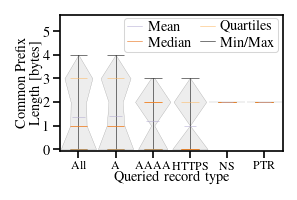

#### [`dns_r_ipv6_addrs_hist_all_w_same_addr.pdf`](04_cbor4dns_eval/plots/dns_r_ipv6_addrs_hist_all_w_same_addr.pdf)

,size,mean,min,median,max,quartiles
All,5666695,7.12298,0,5,16,"[5, 5, 7]"
A,247050,6.160061,0,5,15,"[5, 5, 7]"
AAAA,2763538,7.113141,0,6,16,"[5, 6, 7]"
HTTPS,2656053,7.222785,0,5,15,"[5, 5, 12]"
PTR,54,7.0,7,7,7,"[7, 7, 7]"


<Figure size 191.819x118.55 with 0 Axes>

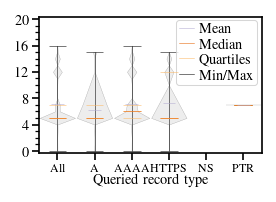

In [23]:
ONLY_PAPER = True      # set to False to plot with filters based message types and datasets
# LABEL_YAXIS = True     # set to False if you want to omit the label of the y-axis (like in the paper)
LABEL_YAXIS = False

for prots in [["dns", "mdns"], ["dns"], ["mdns"]]:  # "xlayer" not that interesting: all or nothing
    for msgs in [["r"]]:  # "q" queries do not contain multiple addresses, naturally
        for dataset_name, dataset in [
            ("all", None),
            #("iot", ["yourthings", "iotfinder", "moniotr"]),
            #("tranco", ["tranco"])
        ]:
            for ignore_same_addrs in [False, True]:
                for addr_type in ["ipv4", "ipv6"]:
                    violin_stats = {}
                    df = pandas.DataFrame()
                    for qtype in [None, "A", "AAAA", 
                                  "HTTPS", "NS",
                                  "PTR"]:
                        colname = qtype if qtype is not None else "All"
                        size, df[colname] = aggregate_addr_hist(
                            [
                                DNSCBOR_EVAL_DIR / "output_datasets" / "dns_addrs_hist_iot.csv",
                                DNSCBOR_EVAL_DIR / "output_datasets" / "dns_addrs_hist_tranco.csv",
                            ],
                            addr_type,
                            datasets=dataset,
                            prots=prots,
                            msgs=msgs,
                            qtypes=[qtype] if qtype else None,
                            ignore_same_addrs=ignore_same_addrs,
                        )
                        if not df[colname].isna().all():
                            df.loc[df[colname].isna(), colname] = 0
                        else:
                            continue
                        violin_stats[colname] = hist_violin_stats(df, colname)
                        violin_stats[colname]["size"] = size
                    if not violin_stats:
                        continue
                    filename = (
                        f"dns{('_' + '_'.join(prots)) if prots != ['dns', 'mdns'] else ''}_{''.join(msgs)}_"
                        f"{addr_type}_addrs_hist_{dataset_name}_"
                        f"{'wo' if ignore_same_addrs else 'w'}_same_addr"
                    )
                    IPython.display.display(
                        IPython.display.Markdown(
                            f"#### [`{filename}.pdf`]"
                            f"({DNSCBOR_EVAL_DIR.relative_to(pathlib.Path.cwd()) / 'plots' / filename}.pdf)"
                        )
                    )
                    IPython.display.display(
                        pandas.DataFrame(violin_stats).T[["size", "mean", "min", "median", "max", "quantiles"]].rename(
                            columns={"quantiles": "quartiles"}
                        )
                    )
                    plot_violin_stats(
                        df,
                        violin_stats,
                        "Common Prefix\nLength [bytes]" if addr_type == "ipv4" or LABEL_YAXIS else None,
                        DNSCBOR_EVAL_DIR / "plots" / f"{filename}.pdf",
                        ylim=(-0.1, 5.7) if addr_type == "ipv4" else (-0.4, 20.4),
                        yticks=range(0, 6, 1) if addr_type == "ipv4" else range(0, 21, 4),
                        figstyle="halfcolumn",
                        figsize_factor=(1.0, 1.0),
                        #legend_ncol=1,
                        legend_ncol=2 if addr_type == "ipv4" else 1,
                        legend_loc="upper right",
                        legend_anchor=(1.01, 1.03),
                        yaxis_minor_locator=matplotlib.ticker.MultipleLocator(1) if addr_type == "ipv6" else None,
                    )
                if ONLY_PAPER:
                    break
            if ONLY_PAPER:
                break
        if ONLY_PAPER:
            break
    if ONLY_PAPER:
        break